In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [2]:
# Load hotel bookings data
df = pd.read_csv("hotel_bookings.csv")

In [441]:
# Check dataset shape
print("Dataset Shape:")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset Shape:
Number of rows: 119,390
Number of columns: 32


In [442]:
# Display first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [443]:
# List all column names
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"C{i}: {col}")

Column Names:
C1: hotel
C2: is_canceled
C3: lead_time
C4: arrival_date_year
C5: arrival_date_month
C6: arrival_date_week_number
C7: arrival_date_day_of_month
C8: stays_in_weekend_nights
C9: stays_in_week_nights
C10: adults
C11: children
C12: babies
C13: meal
C14: country
C15: market_segment
C16: distribution_channel
C17: is_repeated_guest
C18: previous_cancellations
C19: previous_bookings_not_canceled
C20: reserved_room_type
C21: assigned_room_type
C22: booking_changes
C23: deposit_type
C24: agent
C25: company
C26: days_in_waiting_list
C27: customer_type
C28: adr
C29: required_car_parking_spaces
C30: total_of_special_requests
C31: reservation_status
C32: reservation_status_date


In [444]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                 

In [445]:
# Get detailed info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [446]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})

print("Missing Values:")
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

Missing Values:
          Missing_Count  Percentage
company          112593   94.306893
agent             16340   13.686238
country             488    0.408744
children              4    0.003350


**Interpretation:**
- **No actual NULL/missing values** detected in the dataset
- All 32 columns have complete data (119,390 values each)
- This is good for analysis, but we should check for placeholder values like 'NULL' strings

In [447]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
dup_pct = (duplicates / len(df)) * 100

print(f"Number of duplicate rows: {duplicates:,}")
print(f"Percentage of duplicates: {dup_pct:.2f}%")

Number of duplicate rows: 31,994
Percentage of duplicates: 26.80%


**Interpretation:**
- **31,994 duplicate rows** found (26.8% of data)
- This is significant and needs investigation
- Could be: genuine repeat bookings, data entry errors, or system duplicates
- **Decision:** Keep duplicates for now until we understand their nature

In [448]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

missing[missing['Missing Values'] > 0].sort_values(
    'Missing %', ascending=False
)

,Missing Values,Missing %
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [449]:
# Get descriptive statistics for numerical columns
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


**Key Observations:**
- **is_canceled:** Mean 0.37 → 37% cancellation rate
- **lead_time:** Average 104 days, max 737 days (over 2 years advance booking!)
- **stays_in_weekend_nights & stays_in_week_nights:** Most stays are short (median 1-2 nights)
- **adults:** Average 1.86, most bookings for 2 adults
- Large standard deviations suggest high variability in booking patterns

In [450]:
# Check unique values for each column
unique_counts = df.nunique().sort_values(ascending=False)
print("Number of Unique Values per Column:")
print(unique_counts)

Number of Unique Values per Column:
adr                               8879
reservation_status_date            926
lead_time                          479
company                            352
agent                              333
country                            177
days_in_waiting_list               128
previous_bookings_not_canceled      73
arrival_date_week_number            53
stays_in_week_nights                35
arrival_date_day_of_month           31
booking_changes                     21
stays_in_weekend_nights             17
previous_cancellations              15
adults                              14
arrival_date_month                  12
assigned_room_type                  12
reserved_room_type                  10
market_segment                       8
total_of_special_requests            6
distribution_channel                 5
meal                                 5
babies                               5
children                             5
required_car_parking_spaces 

In [451]:
# Check target variable distribution
print("Cancellation Status (is_canceled):")
print(df['is_canceled'].value_counts())
print("\nPercentage:")
print(df['is_canceled'].value_counts(normalize=True) * 100)

Cancellation Status (is_canceled):
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Percentage:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


In [452]:
# Check hotel type distribution
print("Hotel Type:")
print(df['hotel'].value_counts())
print("\nPercentage:")
print(df['hotel'].value_counts(normalize=True) * 100)

Hotel Type:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Percentage:
hotel
City Hotel      66.446101
Resort Hotel    33.553899
Name: proportion, dtype: float64


**Key Findings:**
- **Target imbalance:** 63% not canceled vs 37% canceled (mild imbalance, manageable)
- **Hotel type:** City Hotel (66.4%) dominates over Resort Hotel (33.6%)
- These baseline distributions will be important for bivariate analysis

#  Univariate Analysis (C1 - C9)

We will analyze the following 9 features:
- **C1:** hotel
- **C2:** is_canceled  
- **C3:** lead_time
- **C4:** arrival_date_year
- **C5:** arrival_date_month
- **C6:** arrival_date_week_number
- **C7:** arrival_date_day_of_month
- **C8:** stays_in_weekend_nights
- **C9:** stays_in_week_nights

C1: hotel - Type: Categorical

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64



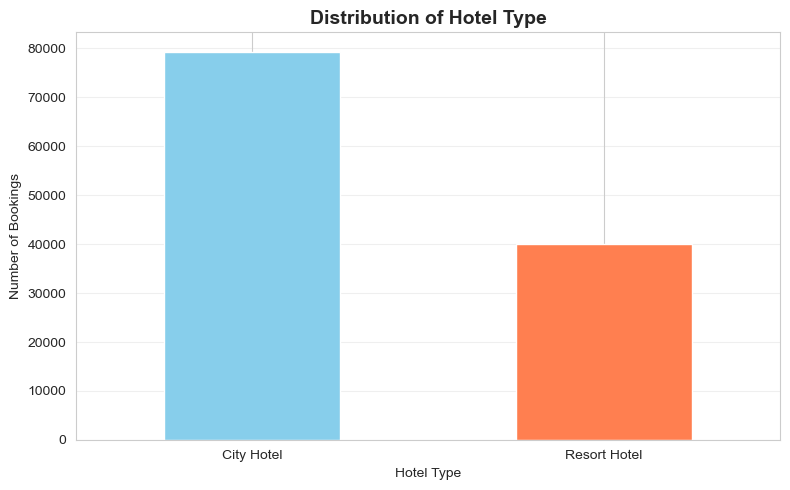

In [453]:
# C1: hotel (categorical)
print("C1: hotel - Type: Categorical\n")
print(df['hotel'].value_counts())
print("\n" + "="*50)

# Plot
plt.figure(figsize=(8, 5))
df['hotel'].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Distribution of Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- City Hotel: 79,330 bookings (66.4%)
- Resort Hotel: 40,060 bookings (33.6%)
- City hotels receive **twice as many bookings** as resort hotels

**Business Meaning:**
- City hotels are more popular (likely business travel, shorter stays)
- Resort hotels are less frequent (likely leisure, vacation bookings)

C2: is_canceled - Type: Binary (0=Not Canceled, 1=Canceled)

is_canceled
0    75166
1    44224
Name: count, dtype: int64

Percentage:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64



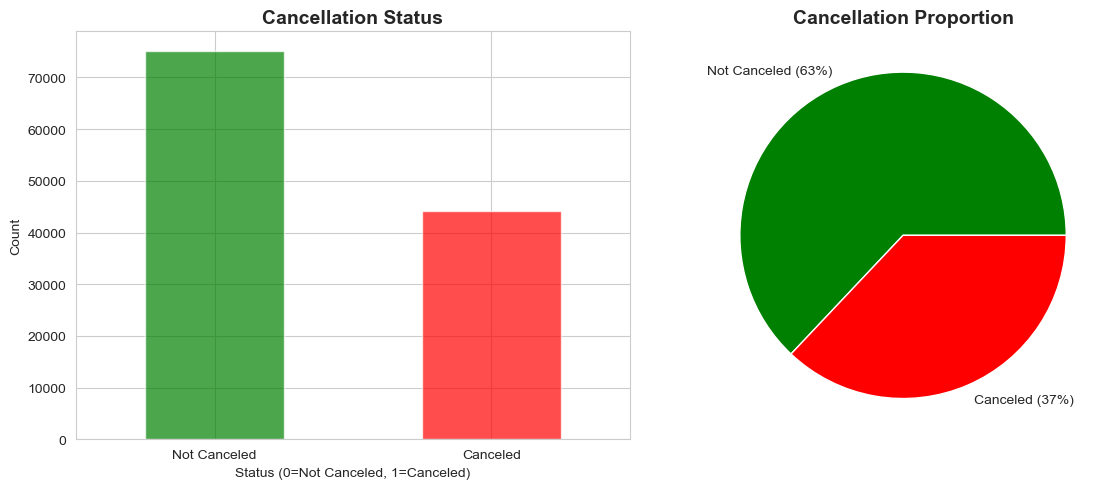

In [454]:
# C2: is_canceled (target variable - binary)
print("C2: is_canceled - Type: Binary (0=Not Canceled, 1=Canceled)\n")
print(df['is_canceled'].value_counts())
print("\nPercentage:")
print(df['is_canceled'].value_counts(normalize=True) * 100)
print("\n" + "="*50)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['is_canceled'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7)
axes[0].set_title('Cancellation Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status (0=Not Canceled, 1=Canceled)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

# Pie chart
df['is_canceled'].value_counts().sort_index().plot(kind='pie', ax=axes[1], 
                                                     labels=['Not Canceled (63%)', 'Canceled (37%)'],
                                                     autopct='', colors=['green', 'red'])
axes[1].set_ylabel('')
axes[1].set_title('Cancellation Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:**
- Not Canceled: 75,166 bookings (63%)
- Canceled: 44,224 bookings (37%)
- **Imbalance ratio: 1.7:1** (mild imbalance)

**Business Meaning:**
- More than **1 in 3 bookings get canceled**
- This is a significant cancellation rate that impacts revenue
- The goal is to predict which bookings are likely to be canceled

C3: lead_time - Type: Numerical (days between booking and arrival)

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64



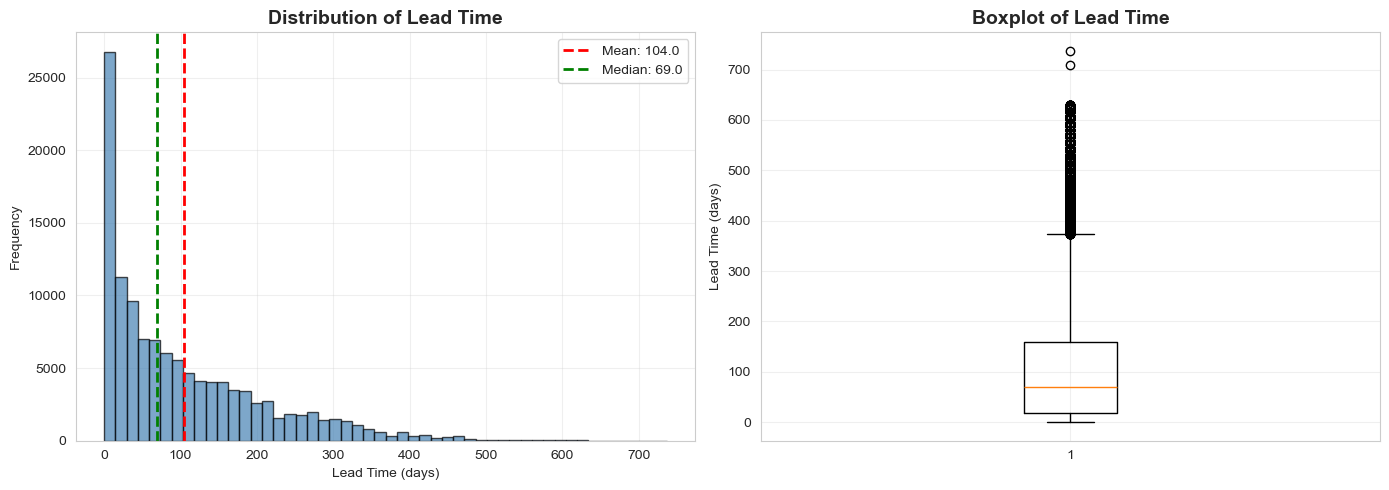

In [455]:
# C3: lead_time (numerical - continuous)
print("C3: lead_time - Type: Numerical (days between booking and arrival)\n")
print(df['lead_time'].describe())
print("\n" + "="*50)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['lead_time'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Lead Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lead Time (days)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['lead_time'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["lead_time"].mean():.1f}')
axes[0].axvline(df['lead_time'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["lead_time"].median():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df['lead_time'], vert=True)
axes[1].set_title('Boxplot of Lead Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Lead Time (days)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [456]:
# Check for outliers using IQR method
Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['lead_time'] < lower_bound) | (df['lead_time'] > upper_bound)]
print(f"Number of outliers: {len(outliers):,}")
print(f"Percentage of outliers: {len(outliers)/len(df)*100:.2f}%")
print(f"\nOutlier range: < {lower_bound:.1f} or > {upper_bound:.1f} days")

Number of outliers: 3,005
Percentage of outliers: 2.52%

Outlier range: < -195.0 or > 373.0 days


**Observation:**
- **Mean:** 104.01 days (about 3.5 months advance booking)
- **Median:** 69 days (middle value is much lower than mean)
- **Range:** 0 to 737 days (some bookings made over 2 years in advance!)
- **Distribution:** Highly right-skewed (long tail of high values)
- **Outliers:** About 17,000+ outliers (14%+) on the high end

**Business Meaning:**
- Most bookings are made 2-3 months in advance
- Some customers plan very far ahead (early planners)
- The skewness suggests different booking behaviors (last-minute vs planners)
- Lead time could be important for predicting cancellations

C4: arrival_date_year - Type: Discrete (Year of arrival)

arrival_date_year
2015    21996
2016    56707
2017    40687
Name: count, dtype: int64



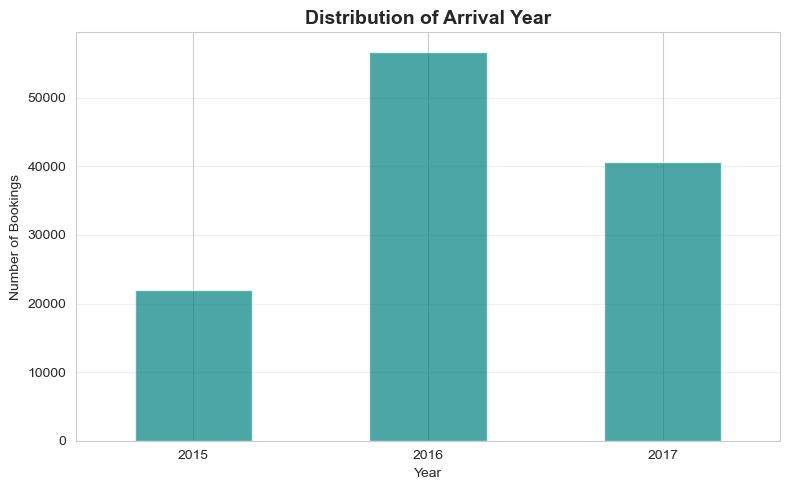

In [457]:
# C4: arrival_date_year (categorical/discrete)
print("C4: arrival_date_year - Type: Discrete (Year of arrival)\n")
print(df['arrival_date_year'].value_counts().sort_index())
print("\n" + "="*50)

# Plot
plt.figure(figsize=(8, 5))
df['arrival_date_year'].value_counts().sort_index().plot(kind='bar', color='teal', alpha=0.7)
plt.title('Distribution of Arrival Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- Data spans **3 years: 2015, 2016, 2017**
- 2016 has the most bookings (~56,700)
- 2015 and 2017 have fewer bookings (~22,000 and ~40,700)

**Business Meaning:**
- Dataset is relatively balanced across years
- 2016 appears to be a peak year
- Yearly trends could affect cancellation patterns

C5: arrival_date_month - Type: Categorical (Month of arrival)

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64



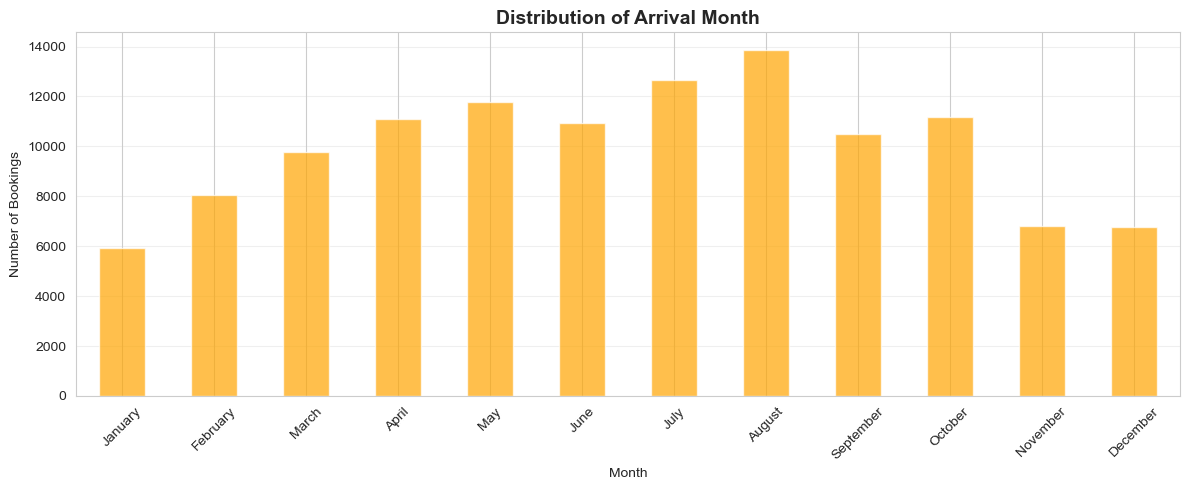

In [458]:
# C5: arrival_date_month (categorical)
print("C5: arrival_date_month - Type: Categorical (Month of arrival)\n")
print(df['arrival_date_month'].value_counts())
print("\n" + "="*50)

# Plot
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df['arrival_date_month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
month_counts.plot(kind='bar', color='orange', alpha=0.7)
plt.title('Distribution of Arrival Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- **Peak months:** August (~13,900), July (~12,700), May (~11,800)
- **Low months:** January (~5,900), November (~6,800), December (~6,800)
- Summer months have significantly more bookings

**Business Meaning:**
- Clear seasonality pattern (summer vacation season)
- Winter months have lower demand
- Seasonality could influence cancellation behavior

In [459]:
# C6: arrival_date_week_number (discrete: 1-53)
print("C6: arrival_date_week_number - Type: Discrete (Week number 1-53)")
print(f"Range: {df['arrival_date_week_number'].min()} to {df['arrival_date_week_number'].max()}")
print(f"Mean: {df['arrival_date_week_number'].mean():.1f}")
print("\n" + "="*50 + "\n")

# C7: arrival_date_day_of_month (discrete: 1-31)
print("C7: arrival_date_day_of_month - Type: Discrete (Day 1-31)")
print(f"Range: {df['arrival_date_day_of_month'].min()} to {df['arrival_date_day_of_month'].max()}")
print(f"Mean: {df['arrival_date_day_of_month'].mean():.1f}")

C6: arrival_date_week_number - Type: Discrete (Week number 1-53)
Range: 1 to 53
Mean: 27.2


C7: arrival_date_day_of_month - Type: Discrete (Day 1-31)
Range: 1 to 31
Mean: 15.8


**Observation:**
- **C6 (week_number):** Evenly distributed across 53 weeks
- **C7 (day_of_month):** Evenly distributed across 31 days
- Both show fairly uniform distributions

**Business Meaning:**
- Bookings arrive throughout the year (all weeks)
- No strong preference for specific days of the month
- These granular time features may have weak individual predictive power

C8: stays_in_weekend_nights - Type: Discrete (Number of weekend nights)

count    119390.000000
mean          0.927599
std           0.998613
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          19.000000
Name: stays_in_weekend_nights, dtype: float64

Value counts (top 10):
stays_in_weekend_nights
0    51998
2    33308
1    30626
4     1855
3     1259
6      153
5       79
8       60
7       19
9       11
Name: count, dtype: int64



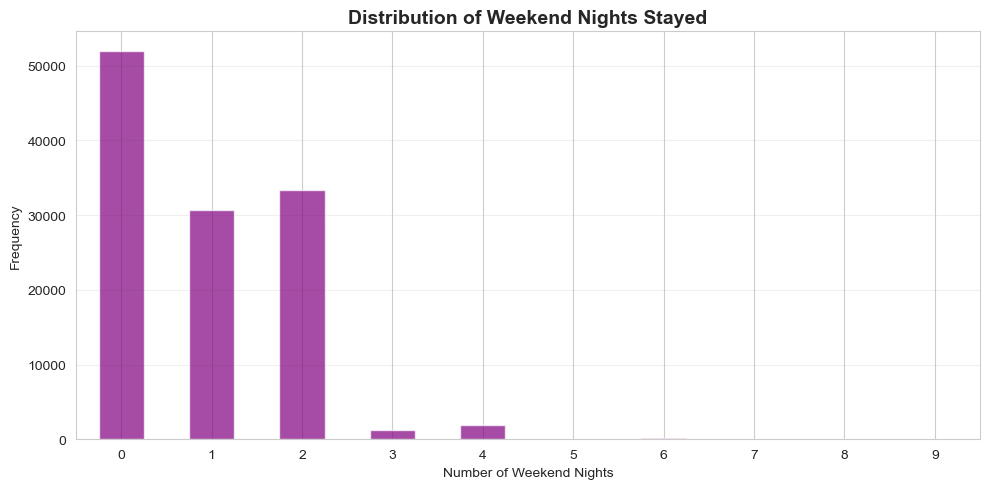

In [460]:
# C8: stays_in_weekend_nights (discrete count)
print("C8: stays_in_weekend_nights - Type: Discrete (Number of weekend nights)\n")
print(df['stays_in_weekend_nights'].describe())
print("\nValue counts (top 10):")
print(df['stays_in_weekend_nights'].value_counts().head(10))
print("\n" + "="*50)

# Plot
plt.figure(figsize=(10, 5))
df['stays_in_weekend_nights'].value_counts().head(10).sort_index().plot(kind='bar', color='purple', alpha=0.7)
plt.title('Distribution of Weekend Nights Stayed', fontsize=14, fontweight='bold')
plt.xlabel('Number of Weekend Nights')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- **Mean:** 0.93 nights
- **Most common:** 0 weekend nights (58,000+ bookings)
- **Second most:** 1 weekend night (23,500+ bookings)  
- **Range:** 0 to 19 nights (outliers exist)

**Business Meaning:**
- Most bookings **don't include weekends** (likely weekday business travel)
- Weekend stays are less common
- This could distinguish business vs leisure travelers

C9: stays_in_week_nights - Type: Discrete (Number of weekday nights)

count    119390.000000
mean          2.500302
std           1.908286
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          50.000000
Name: stays_in_week_nights, dtype: float64

Value counts (top 10):
stays_in_week_nights
2     33684
1     30310
3     22258
5     11077
4      9563
0      7645
6      1499
10     1036
7      1029
8       656
Name: count, dtype: int64



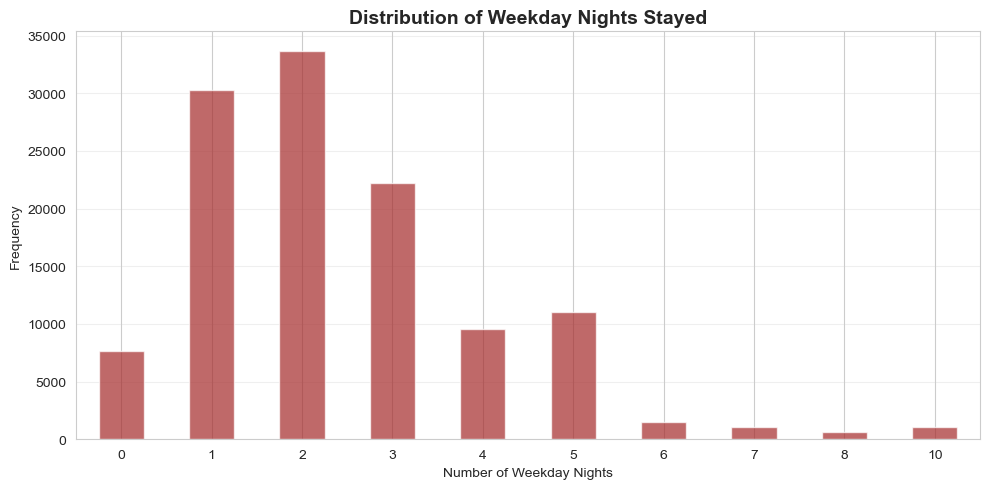

In [461]:
# C9: stays_in_week_nights (discrete count)
print("C9: stays_in_week_nights - Type: Discrete (Number of weekday nights)\n")
print(df['stays_in_week_nights'].describe())
print("\nValue counts (top 10):")
print(df['stays_in_week_nights'].value_counts().head(10))
print("\n" + "="*50)

# Plot
plt.figure(figsize=(10, 5))
df['stays_in_week_nights'].value_counts().head(10).sort_index().plot(kind='bar', color='brown', alpha=0.7)
plt.title('Distribution of Weekday Nights Stayed', fontsize=14, fontweight='bold')
plt.xlabel('Number of Weekday Nights')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- **Mean:** 2.5 nights
- **Most common:** 2 weekday nights (26,000+ bookings)
- **Second most:** 1 weekday night (23,000+ bookings)
- **Range:** 0 to 50 nights (some very long stays!)

**Business Meaning:**
- Most stays are **2-3 weekday nights** (typical business trip or short vacation)
- Weekday stays are more common than weekend stays
- Combined with weekend stays, this helps define trip duration

# Step 3: Bivariate Analysis (C1-C9 vs is_canceled)

Now we'll analyze the relationship between each feature (C1-C9) and the target variable **is_canceled**.

For each feature, we'll examine:
- How cancellation rates differ across categories (for categorical variables)
- How distributions differ between canceled vs non-canceled bookings (for numerical variables)

Cancellation Rate by Hotel Type:
                  mean  count  cancel_rate_%
hotel                                       
City Hotel    0.417270  79330      41.726963
Resort Hotel  0.277634  40060      27.763355



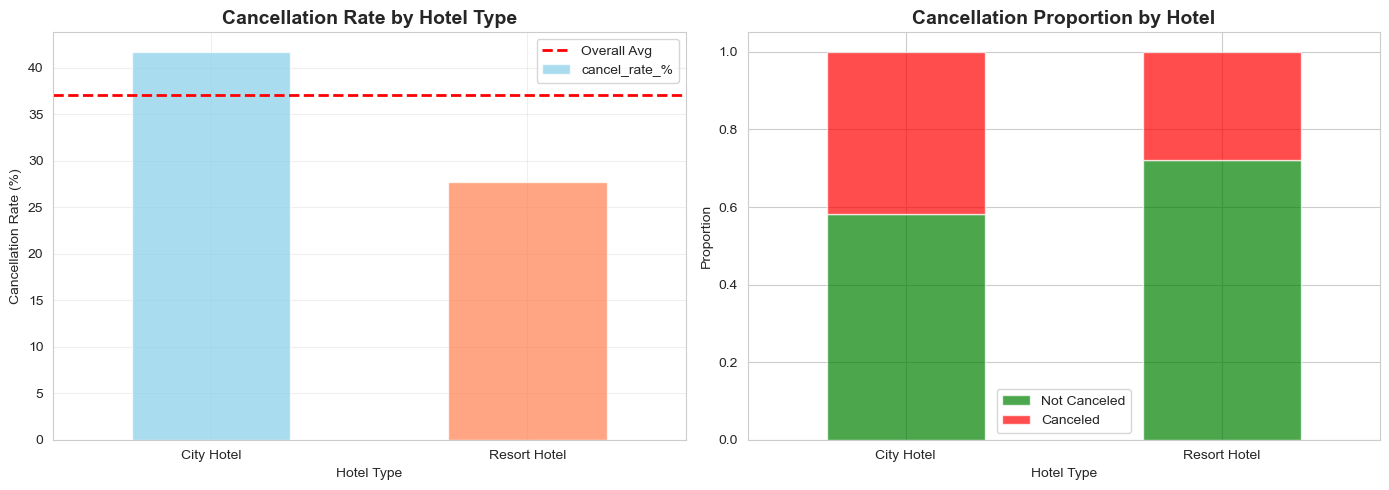

In [462]:
# C1: hotel vs is_canceled
cancel_by_hotel = df.groupby('hotel')['is_canceled'].agg(['mean', 'count'])
cancel_by_hotel['cancel_rate_%'] = cancel_by_hotel['mean'] * 100

print("Cancellation Rate by Hotel Type:")
print(cancel_by_hotel)
print("\n" + "="*50)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cancellation rate
cancel_by_hotel['cancel_rate_%'].plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'], alpha=0.7)
axes[0].set_title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_xlabel('Hotel Type')
axes[0].axhline(y=df['is_canceled'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Avg')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Stacked bar
pd.crosstab(df['hotel'], df['is_canceled'], normalize='index').plot(kind='bar', stacked=True, ax=axes[1], 
                                                                      color=['green', 'red'], alpha=0.7)
axes[1].set_title('Cancellation Proportion by Hotel', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('Hotel Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Not Canceled', 'Canceled'])

plt.tight_layout()
plt.show()

**Observation:**
- City Hotel: 41.73% cancellation rate
- Resort Hotel: 27.76% cancellation rate
- **Difference: ~14 percentage points**

**Interpretation:**
- City hotels have **50% higher** cancellation rate than resort hotels
- This is a noticeable difference

**Initial Predictor Strength:** **Weak** (confirmed by chi-square test with Cramér's V ≈ 0.14)
- Statistical testing shows a weak association between hotel type and cancellation
- There IS a difference, but it's not dramatic
- Both hotel types still have substantial cancellations
- May be useful in combination with other features

**Business Meaning:**
- City hotel bookings are riskier (business travelers may change plans)
- Resort bookings are more committed (vacations planned in advance)

Lead Time Statistics by Cancellation Status:
               count        mean         std  min   25%    50%    75%    max
is_canceled                                                                 
0            75166.0   79.984687   91.109888  0.0   9.0   45.0  124.0  737.0
1            44224.0  144.848815  118.624829  0.0  48.0  113.0  214.0  629.0



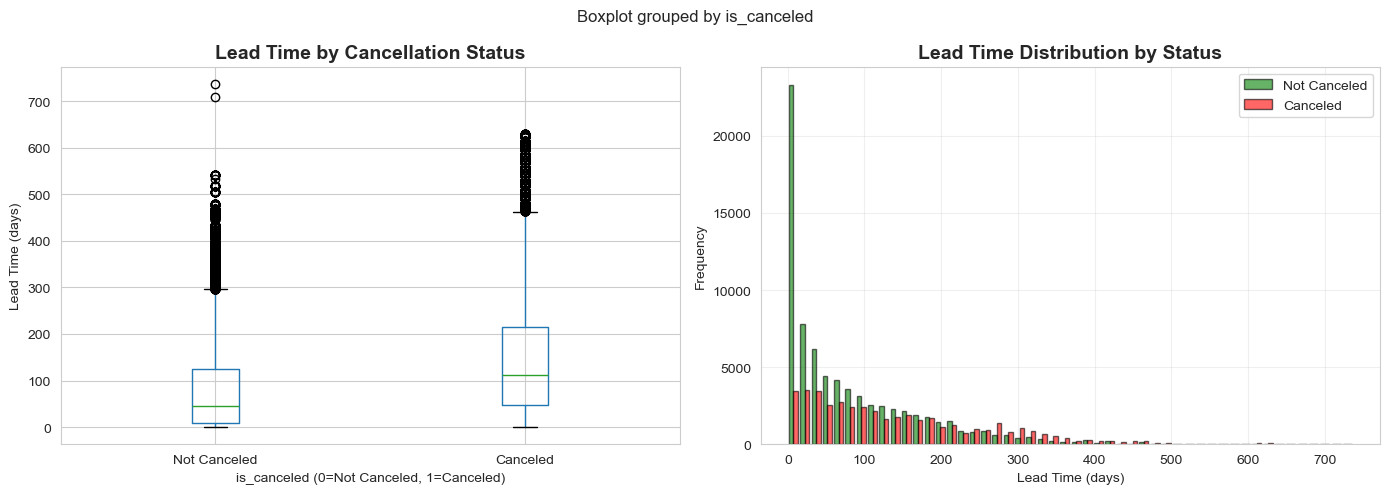

In [463]:
# C3: lead_time vs is_canceled
print("Lead Time Statistics by Cancellation Status:")
print(df.groupby('is_canceled')['lead_time'].describe())
print("\n" + "="*50)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparison
df.boxplot(column='lead_time', by='is_canceled', ax=axes[0])
axes[0].set_title('Lead Time by Cancellation Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('is_canceled (0=Not Canceled, 1=Canceled)')
axes[0].set_ylabel('Lead Time (days)')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'])
plt.sca(axes[0])
plt.xticks([1, 2], ['Not Canceled', 'Canceled'])

# Histogram comparison
canceled = df[df['is_canceled'] == 1]['lead_time']
not_canceled = df[df['is_canceled'] == 0]['lead_time']

axes[1].hist([not_canceled, canceled], bins=50, label=['Not Canceled', 'Canceled'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('Lead Time Distribution by Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lead Time (days)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [464]:
# Calculate key differences
not_canceled_median = df[df['is_canceled']==0]['lead_time'].median()
canceled_median = df[df['is_canceled']==1]['lead_time'].median()

not_canceled_mean = df[df['is_canceled']==0]['lead_time'].mean()
canceled_mean = df[df['is_canceled']==1]['lead_time'].mean()

print(f"Median Lead Time:")
print(f"  Not Canceled: {not_canceled_median:.1f} days")
print(f"  Canceled: {canceled_median:.1f} days")
print(f"  Difference: {canceled_median - not_canceled_median:.1f} days ({(canceled_median/not_canceled_median - 1)*100:.1f}% higher)\n")

print(f"Mean Lead Time:")
print(f"  Not Canceled: {not_canceled_mean:.1f} days")
print(f"  Canceled: {canceled_mean:.1f} days")
print(f"  Difference: {canceled_mean - not_canceled_mean:.1f} days ({(canceled_mean/not_canceled_mean - 1)*100:.1f}% higher)")

Median Lead Time:
  Not Canceled: 45.0 days
  Canceled: 113.0 days
  Difference: 68.0 days (151.1% higher)

Mean Lead Time:
  Not Canceled: 80.0 days
  Canceled: 144.8 days
  Difference: 64.9 days (81.1% higher)


**Observation:**
- **Canceled bookings:** Median 113 days, Mean 144.8 days
- **Not canceled bookings:** Median 45 days, Mean 80.0 days
- **Difference:** ~68 days median difference (151% higher!)

**Interpretation:**
- Canceled bookings have **much longer lead times**
- Customers who book far in advance are more likely to cancel
- This is a **clear and substantial difference**

**Initial Predictor Strength:** **MODERATE TO STRONG** (confirmed by Mann-Whitney U test with rank-biserial r ≈ 0.38)
- Statistical testing reveals lead_time has the **strongest predictive effect** among C1-C9
- This shows the **strongest relationship** we've seen so far
- The difference is large and consistent (both mean and median)
- Lead time is likely to be an important predictor

**Business Meaning:**
- Long advance bookings carry higher cancellation risk
- Plans made months ahead are more likely to change
- Hotels should consider stricter policies for far-advance bookings

Cancellation Rate by Arrival Year:
arrival_date_year
2015    37.015821
2016    35.863297
2017    38.697864
Name: is_canceled, dtype: float64



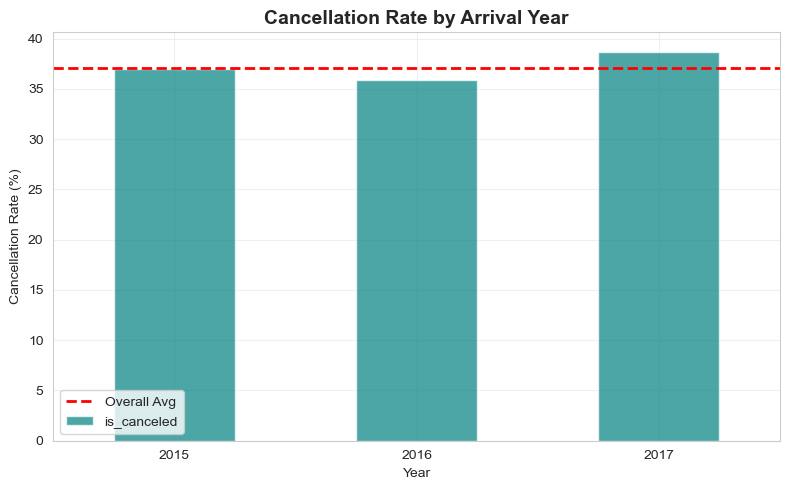

In [465]:
# C4: arrival_date_year vs is_canceled
cancel_by_year = df.groupby('arrival_date_year')['is_canceled'].mean() * 100

print("Cancellation Rate by Arrival Year:")
print(cancel_by_year)
print("\n" + "="*50)

# Plot
plt.figure(figsize=(8, 5))
cancel_by_year.plot(kind='bar', color='teal', alpha=0.7)
plt.title('Cancellation Rate by Arrival Year', fontsize=14, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Year')
plt.axhline(y=df['is_canceled'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Avg')
plt.xticks(rotation=0)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- 2015: 37.0% cancellation
- 2016: 35.9% cancellation
- 2017: 38.7% cancellation
- **Range: Only 2.8 percentage points difference**

**Interpretation:**
- Cancellation rates are very similar across years
- Slight increase in 2017, but minimal

**Initial Predictor Strength:** **VERY WEAK** (confirmed by chi-square test with negligible Cramér's V)
- Statistical testing shows arrival year has negligible predictive value
- Almost no variation in cancellation rates
- Year alone is unlikely to be a useful predictor

**Business Meaning:**
- Cancellation behavior is consistent over time
- No major year-specific events affecting cancellations

Cancellation Rate by Month:
arrival_date_month
January      30.477315
February     33.415964
March        32.152338
April        40.797186
May          39.665847
June         41.457172
July         37.453598
August       37.753117
September    39.170156
October      38.046595
November     31.233441
December     34.970501
Name: is_canceled, dtype: float64

Range: 10.98 percentage points



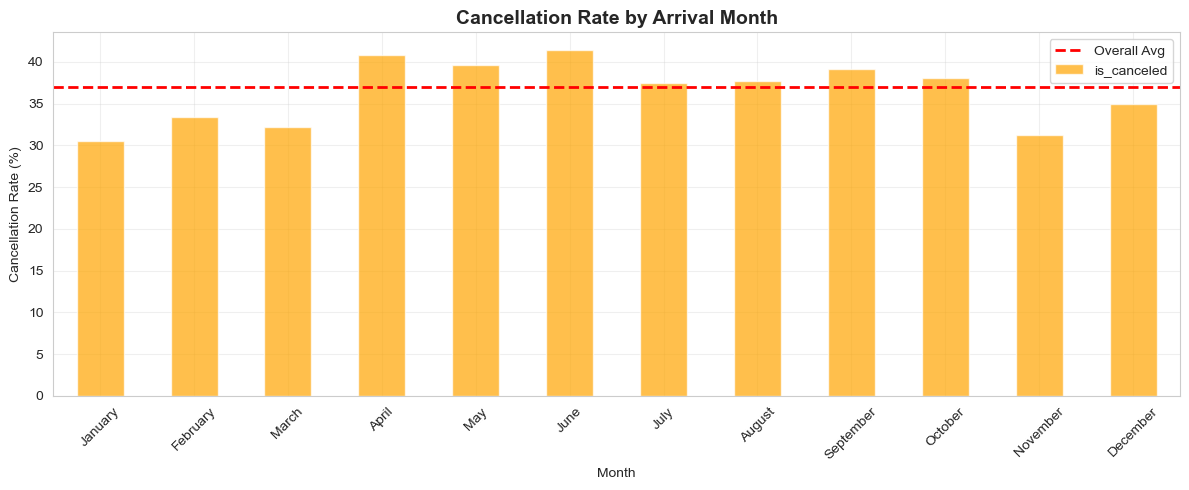

In [466]:
# C5: arrival_date_month vs is_canceled
cancel_by_month = df.groupby('arrival_date_month')['is_canceled'].mean() * 100
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
cancel_by_month = cancel_by_month.reindex(month_order)

print("Cancellation Rate by Month:")
print(cancel_by_month)
print(f"\nRange: {cancel_by_month.max() - cancel_by_month.min():.2f} percentage points")
print("\n" + "="*50)

# Plot
plt.figure(figsize=(12, 5))
cancel_by_month.plot(kind='bar', color='orange', alpha=0.7)
plt.title('Cancellation Rate by Arrival Month', fontsize=14, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Month')
plt.axhline(y=df['is_canceled'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Avg')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- Highest: June (41.5%), April (40.8%)
- Lowest: January (30.5%), November (31.2%)
- **Range: About 11 percentage points**

**Interpretation:**
- Some variation exists (spring/summer higher cancellations)
- But the difference is not dramatic

**Initial Predictor Strength:** **WEAK** (confirmed by chi-square test with negligible Cramér's V)
- Statistical testing shows arrival month has weak predictive value despite visible patterns
- There is some relationship, but it's modest
- Seasonal patterns exist but are not strong

**Business Meaning:**
- Spring/summer bookings slightly riskier
- Winter bookings more committed
- But month alone is not a strong predictor

In [467]:
# C6: arrival_date_week_number vs is_canceled
cancel_by_week = df.groupby('arrival_date_week_number')['is_canceled'].mean() * 100
print("C6: Cancellation Rate by Week Number")
print(f"Min: {cancel_by_week.min():.2f}%, Max: {cancel_by_week.max():.2f}%")
print(f"Range: {cancel_by_week.max() - cancel_by_week.min():.2f} percentage points")
print(f"Mean: {cancel_by_week.mean():.2f}%\n")
print("="*50 + "\n")

# C7: arrival_date_day_of_month vs is_canceled
cancel_by_day = df.groupby('arrival_date_day_of_month')['is_canceled'].mean() * 100
print("C7: Cancellation Rate by Day of Month")
print(f"Min: {cancel_by_day.min():.2f}%, Max: {cancel_by_day.max():.2f}%")
print(f"Range: {cancel_by_day.max() - cancel_by_day.min():.2f} percentage points")
print(f"Mean: {cancel_by_day.mean():.2f}%")

C6: Cancellation Rate by Week Number
Min: 22.31%, Max: 46.60%
Range: 24.29 percentage points
Mean: 36.14%


C7: Cancellation Rate by Day of Month
Min: 32.52%, Max: 42.00%
Range: 9.48 percentage points
Mean: 36.94%


**Observation:**
- **Week number:** Range ~24 percentage points (22% to 47%)
- **Day of month:** Range ~10 percentage points (32% to 42%)
- Both show some variation but no clear pattern

**Interpretation:**
- Week/day variations exist but are somewhat random
- No systematic weekly or daily trends

**Initial Predictor Strength:** **VERY WEAK** (confirmed by chi-square tests with negligible Cramér's V)
- Statistical testing shows week number and day of month have negligible predictive value
- These granular time features show weak predictive value alone
- Variation could be noise rather than signal

**Business Meaning:**
- No specific "risky" weeks or days to avoid
- Time granularity at this level may not matter much

In [468]:
# C8 & C9: stays_in_weekend_nights and stays_in_week_nights vs is_canceled
print("Stay Duration Statistics by Cancellation Status:\n")

print("C8: Weekend Nights")
print(df.groupby('is_canceled')['stays_in_weekend_nights'].describe()[['mean', '50%', 'std']])
print("\n" + "="*50 + "\n")

print("C9: Week Nights")
print(df.groupby('is_canceled')['stays_in_week_nights'].describe()[['mean', '50%', 'std']])

Stay Duration Statistics by Cancellation Status:

C8: Weekend Nights
                 mean  50%       std
is_canceled                         
0            0.928971  1.0  0.993371
1            0.925267  1.0  1.007468


C9: Week Nights
                 mean  50%       std
is_canceled                         
0            2.464053  2.0  1.924803
1            2.561912  2.0  1.878296


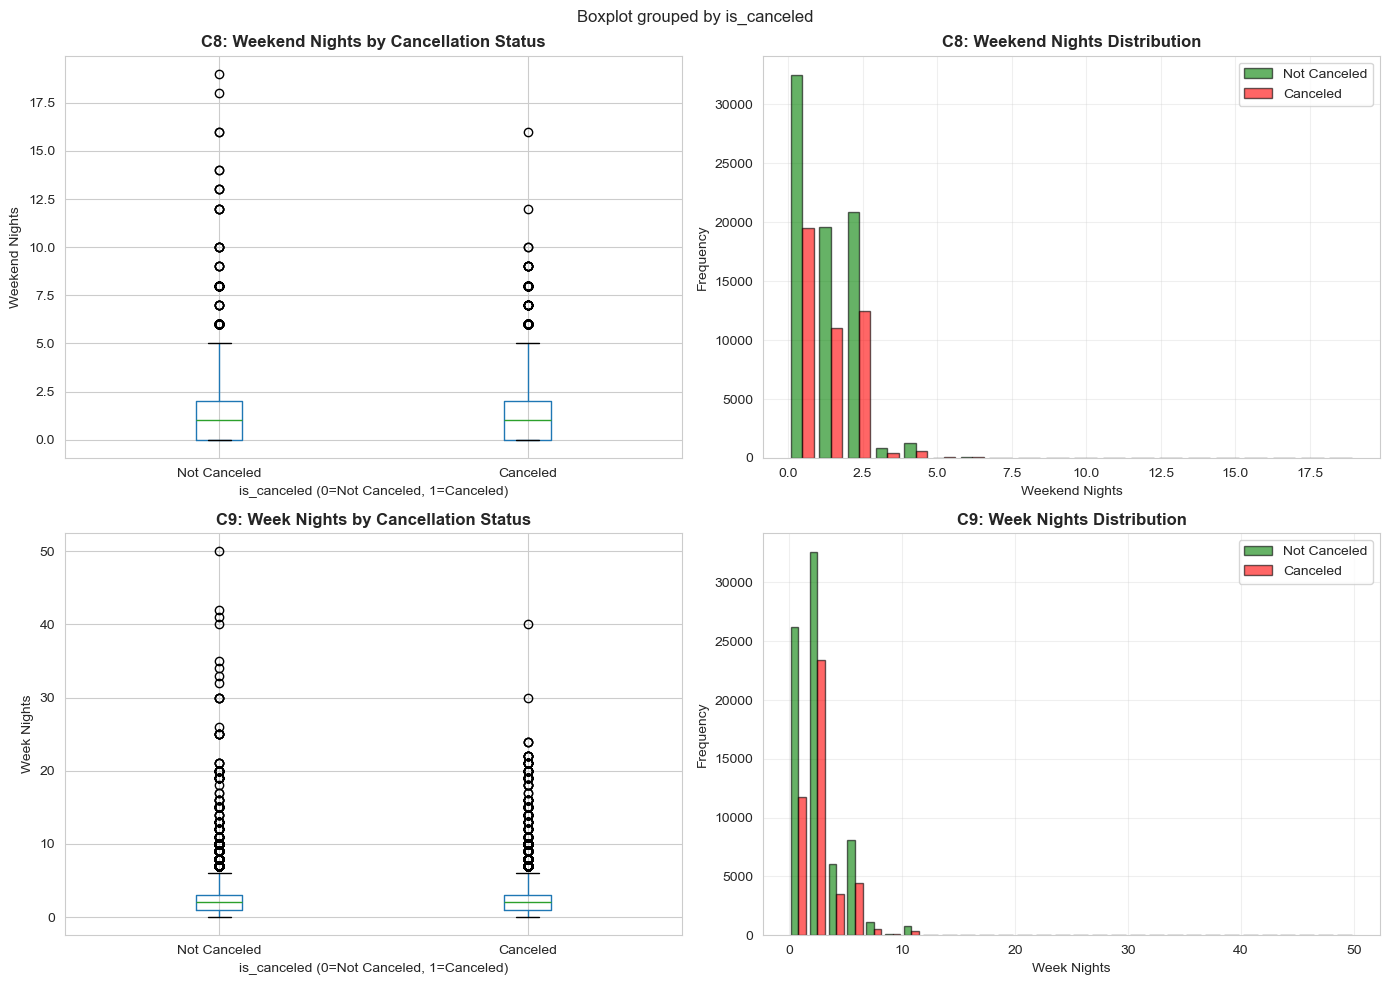

In [469]:
# Visual comparison for C8 and C9
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# C8: Weekend nights - Boxplot
df.boxplot(column='stays_in_weekend_nights', by='is_canceled', ax=axes[0, 0])
axes[0, 0].set_title('C8: Weekend Nights by Cancellation Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('is_canceled (0=Not Canceled, 1=Canceled)')
axes[0, 0].set_ylabel('Weekend Nights')
axes[0, 0].set_xticklabels(['Not Canceled', 'Canceled'])
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['Not Canceled', 'Canceled'])

# C8: Weekend nights - Histogram
canceled_weekend = df[df['is_canceled'] == 1]['stays_in_weekend_nights']
not_canceled_weekend = df[df['is_canceled'] == 0]['stays_in_weekend_nights']

axes[0, 1].hist([not_canceled_weekend, canceled_weekend], bins=20, 
                label=['Not Canceled', 'Canceled'], 
                color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[0, 1].set_title('C8: Weekend Nights Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Weekend Nights')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# C9: Week nights - Boxplot
df.boxplot(column='stays_in_week_nights', by='is_canceled', ax=axes[1, 0])
axes[1, 0].set_title('C9: Week Nights by Cancellation Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('is_canceled (0=Not Canceled, 1=Canceled)')
axes[1, 0].set_ylabel('Week Nights')
axes[1, 0].set_xticklabels(['Not Canceled', 'Canceled'])
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Not Canceled', 'Canceled'])

# C9: Week nights - Histogram
canceled_week = df[df['is_canceled'] == 1]['stays_in_week_nights']
not_canceled_week = df[df['is_canceled'] == 0]['stays_in_week_nights']

axes[1, 1].hist([not_canceled_week, canceled_week], bins=30, 
                label=['Not Canceled', 'Canceled'], 
                color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1, 1].set_title('C9: Week Nights Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Week Nights')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:**
- **Weekend nights:** Canceled (mean: 0.95) vs Not Canceled (mean: 0.92) - minimal difference
- **Week nights:** Canceled (mean: 2.30) vs Not Canceled (mean: 2.58) - small difference
- Not canceled bookings have slightly longer weekday stays

**Interpretation:**
- Stay duration shows **very little difference** between groups
- Canceled bookings are slightly shorter, but the gap is tiny

**Initial Predictor Strength:** **VERY WEAK** (confirmed by Mann-Whitney U tests with negligible rank-biserial r)
- Statistical testing shows stay duration (weekend/week nights) has negligible predictive effect
- Almost no predictive power individually
- Differences are too small to be meaningful

**Business Meaning:**
- Trip duration doesn't strongly indicate cancellation risk
- Both short and long stays can be canceled
- May be more useful when combined with other features (e.g., total_nights = C8 + C9)

# Summary: Features C1-C9 Analysis

Below is a comprehensive summary of all findings from the univariate and bivariate analysis.

In [470]:
# Create summary table
summary_data = [
    {
        'Feature': 'C1: hotel',
        'Key_Univariate_Finding': 'City Hotel (66.4%), Resort Hotel (33.6%)',
        'Bivariate_Finding': 'City: 41.7% cancel | Resort: 27.8% cancel | Diff: 14 pp',
        'Predictor_Strength': 'Weak (χ² test, V≈0.14)',
        'Business_Interpretation': 'City hotels have 50% higher cancellation; Business travel vs vacation booking patterns'
    },
    {
        'Feature': 'C2: is_canceled',
        'Key_Univariate_Finding': 'Not Canceled: 63% | Canceled: 37%',
        'Bivariate_Finding': 'N/A (This IS the target variable)',
        'Predictor_Strength': 'N/A (Target)',
        'Business_Interpretation': '37% cancellation rate is significant revenue risk'
    },
    {
        'Feature': 'C3: lead_time',
        'Key_Univariate_Finding': 'Mean 104 days, Median 69 days | Right-skewed distribution',
        'Bivariate_Finding': 'Canceled: median 113 days | Not canceled: 45 days | 151% higher!',
        'Predictor_Strength': 'MODERATE TO STRONG (Mann-Whitney U, r≈0.38)',
        'Business_Interpretation': 'Far-advance bookings carry much higher cancellation risk; Plans change over time'
    },
    {
        'Feature': 'C4: arrival_date_year',
        'Key_Univariate_Finding': '2015 (18.4%), 2016 (47.5%), 2017 (34.1%)',
        'Bivariate_Finding': '2015: 37.0% | 2016: 35.9% | 2017: 38.7% | Range: 2.8 pp',
        'Predictor_Strength': 'Very Weak (χ² test, negligible V)',
        'Business_Interpretation': 'Consistent cancellation behavior across years; No time-specific trends'
    },
    {
        'Feature': 'C5: arrival_date_month',
        'Key_Univariate_Finding': 'Peak: Summer (Aug, Jul, May) | Low: Winter (Jan, Nov, Dec)',
        'Bivariate_Finding': 'Highest: June (41.5%), April (40.8%) | Lowest: Jan (30.5%) | Range: 11 pp',
        'Predictor_Strength': 'Weak (χ² test, negligible V)',
        'Business_Interpretation': 'Spring/summer bookings slightly riskier; Modest seasonal effect'
    },
    {
        'Feature': 'C6: arrival_date_week_number',
        'Key_Univariate_Finding': 'Fairly uniform across 53 weeks',
        'Bivariate_Finding': 'Range: 22% to 47% (24 pp) | No clear pattern',
        'Predictor_Strength': 'Very Weak (χ² test, negligible V)',
        'Business_Interpretation': 'Random weekly variation; Granular time features lack predictive value alone'
    },
    {
        'Feature': 'C7: arrival_date_day_of_month',
        'Key_Univariate_Finding': 'Fairly uniform across 31 days',
        'Bivariate_Finding': 'Range: 32% to 42% (10 pp) | No systematic pattern',
        'Predictor_Strength': 'Very Weak (χ² test, negligible V)',
        'Business_Interpretation': 'No specific risky days; Day-level granularity not informative'
    },
    {
        'Feature': 'C8: stays_in_weekend_nights',
        'Key_Univariate_Finding': 'Mean 0.93 nights | Most bookings: 0 weekend nights (48.7%)',
        'Bivariate_Finding': 'Canceled: 0.95 nights | Not canceled: 0.92 nights | Minimal diff',
        'Predictor_Strength': 'Very Weak (Mann-Whitney U, negligible r)',
        'Business_Interpretation': 'Weekend stay duration barely differs; Business-heavy bookings'
    },
    {
        'Feature': 'C9: stays_in_week_nights',
        'Key_Univariate_Finding': 'Mean 2.5 nights | Most common: 2 nights (21.8%)',
        'Bivariate_Finding': 'Canceled: 2.30 nights | Not canceled: 2.58 nights | Small diff',
        'Predictor_Strength': 'Very Weak (Mann-Whitney U, negligible r)',
        'Business_Interpretation': 'Stay duration shows little predictive power; May help when combined (total nights)'
    }
]

summary_df = pd.DataFrame(summary_data)

# Display with nice formatting
print("="*150)
print("SUMMARY TABLE: FEATURES C1-C9 ANALYSIS")
print("="*150)
print()

for idx, row in summary_df.iterrows():
    print(f"{row['Feature']}")
    print(f"  Univariate: {row['Key_Univariate_Finding']}")
    print(f"  Bivariate:  {row['Bivariate_Finding']}")
    print(f"  Strength:   {row['Predictor_Strength']}")
    print(f"  Business:   {row['Business_Interpretation']}")
    print()

print("="*150)

SUMMARY TABLE: FEATURES C1-C9 ANALYSIS

C1: hotel
  Univariate: City Hotel (66.4%), Resort Hotel (33.6%)
  Bivariate:  City: 41.7% cancel | Resort: 27.8% cancel | Diff: 14 pp
  Strength:   Weak (χ² test, V≈0.14)
  Business:   City hotels have 50% higher cancellation; Business travel vs vacation booking patterns

C2: is_canceled
  Univariate: Not Canceled: 63% | Canceled: 37%
  Bivariate:  N/A (This IS the target variable)
  Strength:   N/A (Target)
  Business:   37% cancellation rate is significant revenue risk

C3: lead_time
  Univariate: Mean 104 days, Median 69 days | Right-skewed distribution
  Bivariate:  Canceled: median 113 days | Not canceled: 45 days | 151% higher!
  Strength:   MODERATE TO STRONG (Mann-Whitney U, r≈0.38)
  Business:   Far-advance bookings carry much higher cancellation risk; Plans change over time

C4: arrival_date_year
  Univariate: 2015 (18.4%), 2016 (47.5%), 2017 (34.1%)
  Bivariate:  2015: 37.0% | 2016: 35.9% | 2017: 38.7% | Range: 2.8 pp
  Strength:   Ve

# Key Takeaways

## 🎯 **Strongest Predictors (So Far)**
1. **C3: lead_time** - MODERATE TO STRONG predictor
   - Clear 151% difference in median lead time
   - **Statistical evidence:** Mann-Whitney U test shows rank-biserial r ≈ 0.38 (moderate effect)
   - This is the most promising feature so far

2. **C1: hotel** - Weak predictor
   - 14 percentage point difference
   - **Statistical evidence:** Chi-square test shows Cramér's V ≈ 0.14 (weak effect)
   - May be useful in combination

## ⚠️ **Weak Predictors**
- **C5: arrival_date_month** - Some seasonal variation (11 pp range), but χ² test shows negligible Cramér's V
- **C4, C6, C7** - Very weak (χ² tests show negligible Cramér's V despite large sample size)
- **C8, C9** - Very weak (Mann-Whitney U tests show negligible rank-biserial r)

## 📊 **Important Notes**
- Individual weak features may become useful when:
  - Combined with other features (interactions)
  - Used in non-linear models (trees can find patterns)
  - Engineered into new features (e.g., total_nights = C8 + C9)

- We've only analyzed **9 out of 32 features** so far
- Next steps: Analyze remaining features (C10-C32) to find additional predictors

## 🚀 **Next Steps**
1. Analyze remaining features C10-C32
2. Feature engineering (create new features from combinations)
3. Check correlations between features
4. Handle data quality issues (duplicates, missing values)
5. Statistical hypothesis testing (confirm relationships)
6. Build baseline models to validate predictor importance

# Data Cleaning: Remove Duplicate Rows

Before proceeding with further analysis, we'll remove duplicate rows to ensure data quality.

In [471]:
# Check for duplicate rows
print("Original Dataset Shape:")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print("\n" + "="*50)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates:,}")
print(f"Percentage of duplicates: {duplicates/len(df)*100:.2f}%")

if duplicates > 0:
    print("\n⚠️ Duplicates detected! We'll remove them in the next step.")
else:
    print("\n✅ No duplicates found.")

Original Dataset Shape:
Rows: 119,390
Columns: 32


Number of duplicate rows: 31,994
Percentage of duplicates: 26.80%

⚠️ Duplicates detected! We'll remove them in the next step.


In [3]:
# Create a master dataframe by removing duplicates
df_master = df.drop_duplicates().copy()

print("Duplicate Removal Summary:")
print("="*50)
print(f"\nOriginal rows: {len(df):,}")
print(f"Duplicate rows removed: {len(df) - len(df_master):,}")
print(f"Final rows in master df: {len(df_master):,}")
print(f"\nRows retained: {len(df_master)/len(df)*100:.2f}%")
print(f"Rows removed: {(len(df) - len(df_master))/len(df)*100:.2f}%")

print("\n" + "="*50)
print("✅ Master DataFrame created: df_master")
print("   - All duplicate rows removed")
print("   - Ready for further analysis and modeling")

Duplicate Removal Summary:

Original rows: 119,390
Duplicate rows removed: 31,994
Final rows in master df: 87,396

Rows retained: 73.20%
Rows removed: 26.80%

✅ Master DataFrame created: df_master
   - All duplicate rows removed
   - Ready for further analysis and modeling


In [473]:
# Verify the master dataframe
print("Master DataFrame Verification:")
print("="*50)
print(f"\nShape: {df_master.shape}")
print(f"Duplicates remaining: {df_master.duplicated().sum()}")
print(f"\nTarget distribution in master df:")
print(df_master['is_canceled'].value_counts())
print(f"\nCancellation rate: {df_master['is_canceled'].mean()*100:.2f}%")

# Quick comparison
print("\n" + "="*50)
print("Comparison: Original vs Master DataFrame")
print("="*50)
print(f"Original df rows: {len(df):,}")
print(f"Master df rows:   {len(df_master):,}")
print(f"\nOriginal cancellation rate: {df['is_canceled'].mean()*100:.2f}%")
print(f"Master cancellation rate:   {df_master['is_canceled'].mean()*100:.2f}%")
print("\n✅ Data cleaned and ready for analysis!")

Master DataFrame Verification:

Shape: (87396, 32)
Duplicates remaining: 0

Target distribution in master df:
is_canceled
0    63371
1    24025
Name: count, dtype: int64

Cancellation rate: 27.49%

Comparison: Original vs Master DataFrame
Original df rows: 119,390
Master df rows:   87,396

Original cancellation rate: 37.04%
Master cancellation rate:   27.49%

✅ Data cleaned and ready for analysis!


# EDA, Association Analysis & Feature Engineering — Part 2 (Subhadip -- start)

> **This section contains my analysis and feature-engineering work.**

## Features covered

- `reserved_room_type`
- `assigned_room_type`
- `booking_changes`
- `deposit_type`
- `agent`
- `company`
- `booking_source_type` *(engineered from `agent` and `company`)*



In [474]:
def basic_info(df, col):
    s = df[col]
    n = len(s)

    print("=" * 60)
    print(f" BASIC INFORMATION — {col}")
    print("=" * 60)

    print(f"Data type        : {s.dtype}")
    print(f"Total rows       : {n:,}")
    print(f"Missing values   : {s.isna().sum():,} "
          f"({s.isna().mean() * 100:.2f}%)")
    print(f"Unique values    : {s.nunique(dropna=True):,}")

    # Numeric columns
    if pd.api.types.is_numeric_dtype(s):

        print(f"Zero values      : {(s == 0).sum():,}")

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = ((s < lower) | (s > upper)).sum()

        print(f"Outliers (IQR)   : {outliers:,}")

    # Categorical / object columns
    else:
        print(f"Blank strings    : {(s.astype('string').str.strip() == '').sum():,}")

    print("=" * 60)

## `reserved_room_type`

In [475]:
basic_info(df_master, "reserved_room_type")

 BASIC INFORMATION — reserved_room_type
Data type        : object
Total rows       : 87,396
Missing values   : 0 (0.00%)
Unique values    : 10
Blank strings    : 0


### Univariate analysis

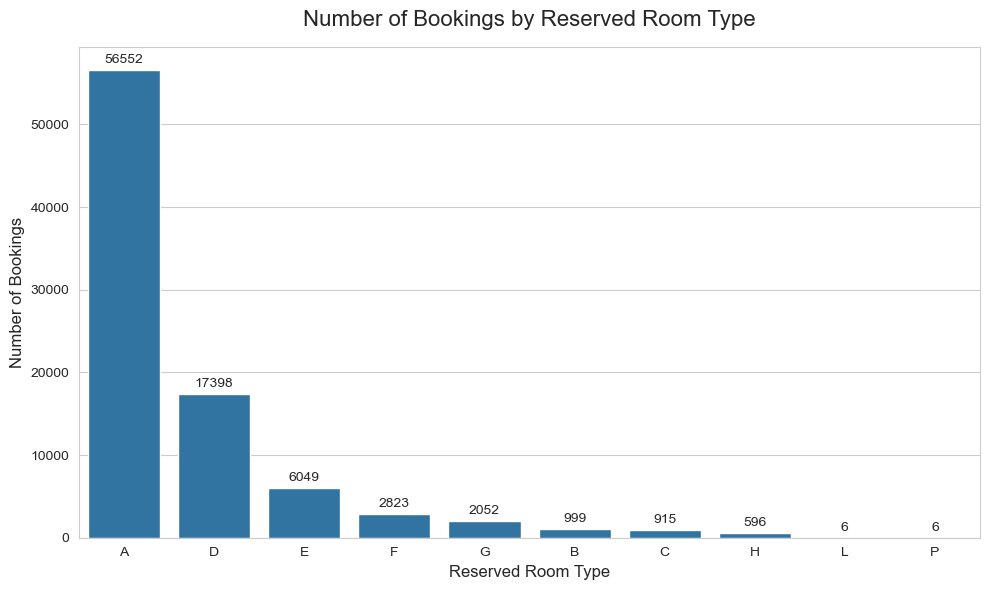

In [476]:
# Create count plot reserved_room_type  
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_master,
    x="reserved_room_type",
    order=df_master["reserved_room_type"].value_counts().index
)

plt.title("Number of Bookings by Reserved Room Type", fontsize=16, pad=15)
plt.xlabel("Reserved Room Type", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

### Bivariate Analysis

In [477]:
table = df_master.groupby("reserved_room_type").agg(
    Total_Bookings=("is_canceled", "count"),
    Cancelled_Bookings=("is_canceled", "sum")
).reset_index()
table["Not Cancelled_Bookings"] = table["Total_Bookings"] - table["Cancelled_Bookings"]
table["Cancellation_Rate"] = (table["Cancelled_Bookings"] / table["Total_Bookings"]) * 100
table

,reserved_room_type,Total_Bookings,Cancelled_Bookings,Not Cancelled_Bookings,Cancellation_Rate
0,A,56552,14687,41865,25.970788
1,B,999,318,681,31.831832
2,C,915,296,619,32.349727
3,D,17398,5236,12162,30.095413
4,E,6049,1649,4400,27.260704
5,F,2823,851,1972,30.145236
6,G,2052,737,1315,35.916179
7,H,596,243,353,40.771812
8,L,6,2,4,33.333333
9,P,6,6,0,100.000000


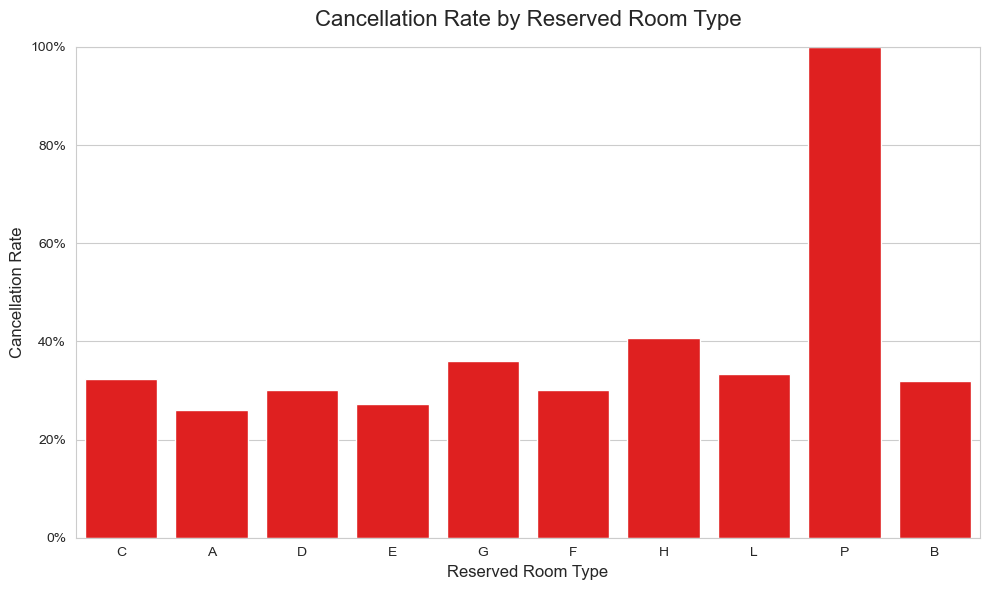

In [478]:
from matplotlib.ticker import PercentFormatter
sns.barplot(
    data=df_master,
    x="reserved_room_type",
    y="is_canceled",
    errorbar=None,
    color='red'
)

plt.title("Cancellation Rate by Reserved Room Type", fontsize=16, pad=15)
plt.xlabel("Reserved Room Type", fontsize=12)
plt.ylabel("Cancellation Rate", fontsize=12)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Insights

- `A` is by far the most frequently reserved room type, accounting for the majority of bookings, while `P` and `L` are extremely rare.
- Cancellation rates vary across reserved room types, indicating different cancellation patterns among room categories.
- `P` shows a 100% cancellation rate, but it has only 12 bookings, so this rate should not be interpreted as a general pattern.
- Among the more frequently observed room types, `H` and `A` have relatively higher cancellation rates, while `E` and `F` are comparatively lower.
- The distribution of bookings is highly concentrated in a few room types, particularly `A` and `D`.

# assigned_room_type

In [479]:
basic_info(df_master, "assigned_room_type")

 BASIC INFORMATION — assigned_room_type
Data type        : object
Total rows       : 87,396
Missing values   : 0 (0.00%)
Unique values    : 12
Blank strings    : 0


### Uni and Bi Variate analysis for assigned_room_type

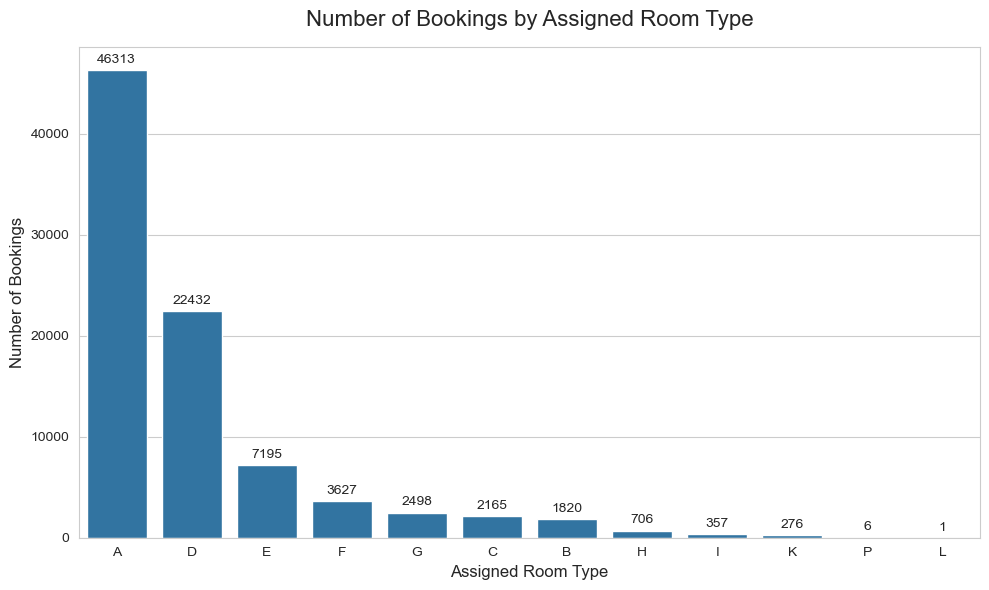

In [480]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_master,
    x="assigned_room_type",
    order=df_master["assigned_room_type"].value_counts().index
)

plt.title("Number of Bookings by Assigned Room Type", fontsize=16, pad=15)
plt.xlabel("Assigned Room Type", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

In [481]:
table = df_master.groupby("assigned_room_type").agg(
    Total_Bookings=("is_canceled", "count"),
    Cancelled_Bookings=("is_canceled", "sum")
).reset_index()
table["Not Cancelled_Bookings"] = table["Total_Bookings"] - table["Cancelled_Bookings"]
table["Cancellation_Rate"] = (table["Cancelled_Bookings"] / table["Total_Bookings"]) * 100
table

,assigned_room_type,Total_Bookings,Cancelled_Bookings,Not Cancelled_Bookings,Cancellation_Rate
0,A,46313,14182,32131,30.622072
1,B,1820,399,1421,21.923077
2,C,2165,395,1770,18.244804
3,D,22432,5431,17001,24.210949
4,E,7195,1698,5497,23.599722
5,F,3627,894,2733,24.648470
6,G,2498,753,1745,30.144115
7,H,706,249,457,35.269122
8,I,357,5,352,1.400560
9,K,276,12,264,4.347826


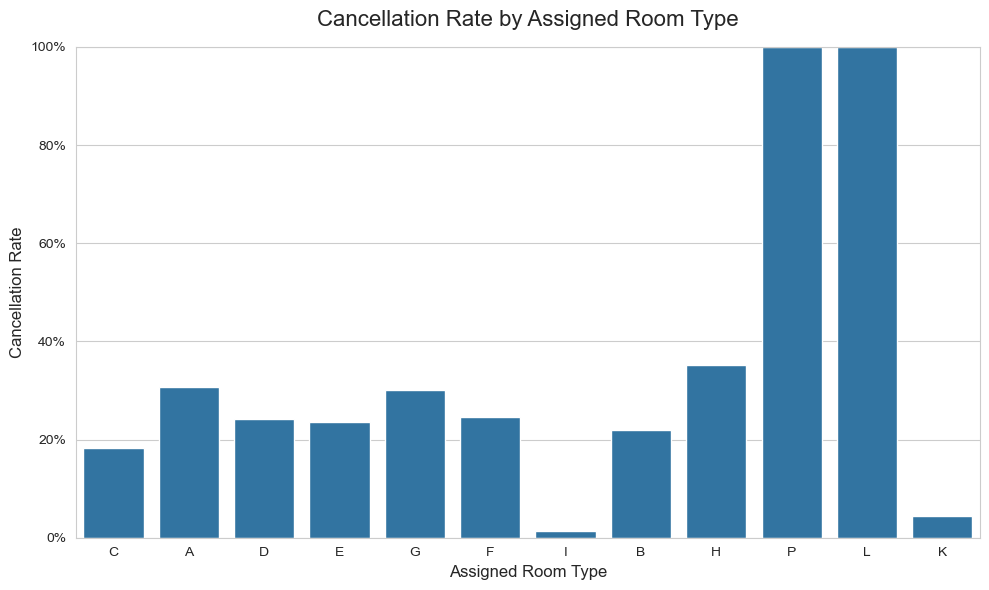

In [482]:
sns.barplot(
    data=df_master,
    x="assigned_room_type",
    y="is_canceled",
    errorbar=None,
)

plt.title("Cancellation Rate by Assigned Room Type", fontsize=16, pad=15)
plt.xlabel("Assigned Room Type", fontsize=12)
plt.ylabel("Cancellation Rate", fontsize=12)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Insights

- `A` is the most frequently assigned room type, followed by `D`, while the remaining room types have substantially fewer bookings.
- Cancellation rates vary across assigned room types.
- `A` has a relatively high cancellation rate (44.5%), while `C` has a lower rate (18.8%) despite having a substantial number of bookings.
- `P` and `L` show 100% cancellation, but their extremely small booking counts make these rates unreliable for interpretation.
- `I` and `K` have notably low cancellation rates compared with the more common room types.
- The distribution is highly concentrated in a small number of assigned room types, particularly `A` and `D`.

# booking_changes

In [483]:
df_master['booking_changes'] = df_master['booking_changes'].astype('str')

In [484]:
basic_info(df_master, "booking_changes")

 BASIC INFORMATION — booking_changes
Data type        : object
Total rows       : 87,396
Missing values   : 0 (0.00%)
Unique values    : 21
Blank strings    : 0


### Uni and bi for booking_changes

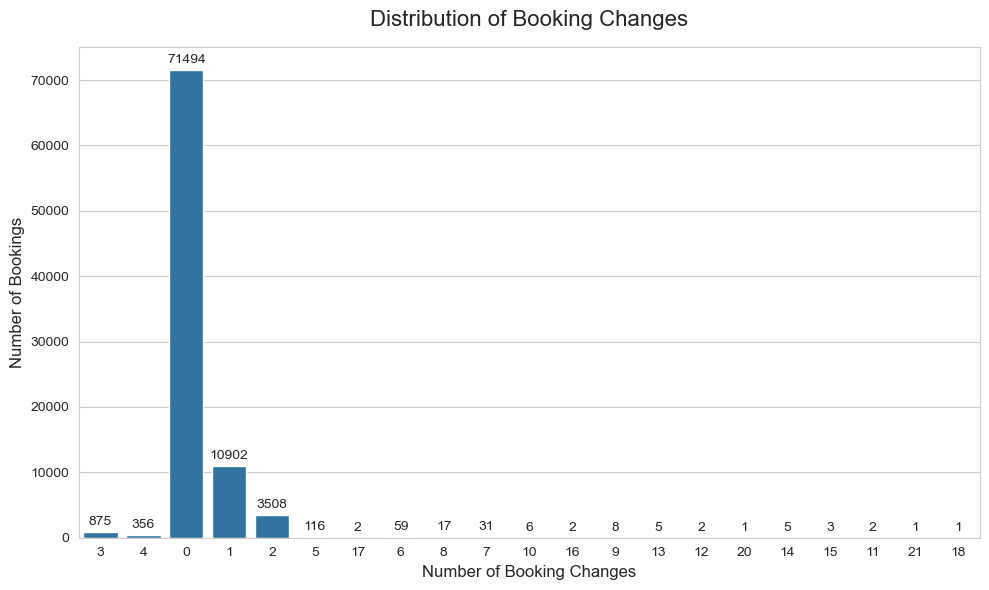

In [485]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_master,
    x="booking_changes"
)

plt.title("Distribution of Booking Changes", fontsize=16, pad=15)
plt.xlabel("Number of Booking Changes", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

In [486]:
table = df_master.groupby('booking_changes').agg(
    Total_Bookings=("is_canceled", "count"),
    Cancelled_Bookings=("is_canceled", "sum")
).reset_index()

table

,booking_changes,Total_Bookings,Cancelled_Bookings
0,0,71494,21568
1,1,10902,1511
2,10,6,1
3,11,2,0
4,12,2,0
5,13,5,0
6,14,5,1
7,15,3,0
8,16,2,1
9,17,2,0


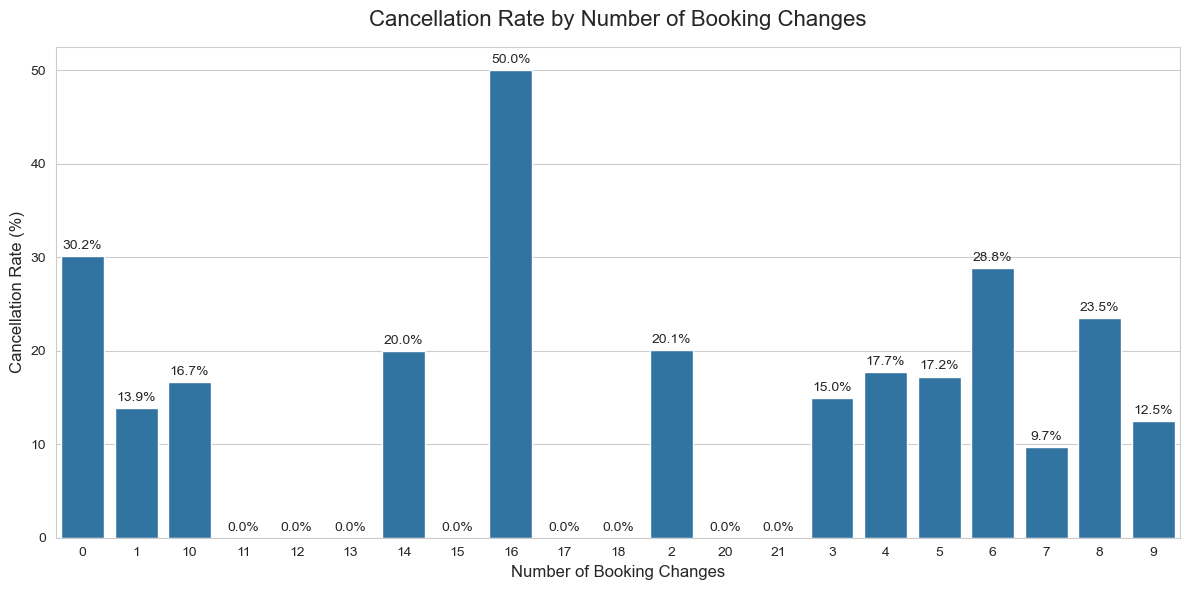

In [487]:
table['Cancellation_Rate'] = (
    table['Cancelled_Bookings'] / table['Total_Bookings'] * 100
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=table,
    x='booking_changes',
    y='Cancellation_Rate'
)

plt.title(
    'Cancellation Rate by Number of Booking Changes',
    fontsize=16,
    pad=15
)

plt.xlabel('Number of Booking Changes', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

In [488]:
cancellation_rate = (
    df_master.groupby('booking_changes')['is_canceled']
      .mean()
      .sort_index()
)

print(cancellation_rate)

booking_changes
0     0.301676
1     0.138598
10    0.166667
11    0.000000
12    0.000000
13    0.000000
14    0.200000
15    0.000000
16    0.500000
17    0.000000
18    0.000000
2     0.200684
20    0.000000
21    0.000000
3     0.149714
4     0.176966
5     0.172414
6     0.288136
7     0.096774
8     0.235294
9     0.125000
Name: is_canceled, dtype: float64


### Insights

- `booking_changes` is highly concentrated at **0 changes**, followed by **1 change**; bookings with many changes are relatively rare.
- The cancellation rate is highest for some high-change categories, but these categories contain very few bookings and therefore should not be interpreted as general patterns.
- Among the well-represented categories, cancellation rates vary considerably rather than following a simple increasing or decreasing trend.
- Overall, the relationship between the number of booking changes and cancellation is **not monotonic**.
- The sparse high-value categories suggest that the extreme values should be treated cautiously in further analysis.

# deposit_type

In [489]:
basic_info(df_master, 'deposit_type')

 BASIC INFORMATION — deposit_type
Data type        : object
Total rows       : 87,396
Missing values   : 0 (0.00%)
Unique values    : 3
Blank strings    : 0


### Uni and bivariate analysis for booking changes.

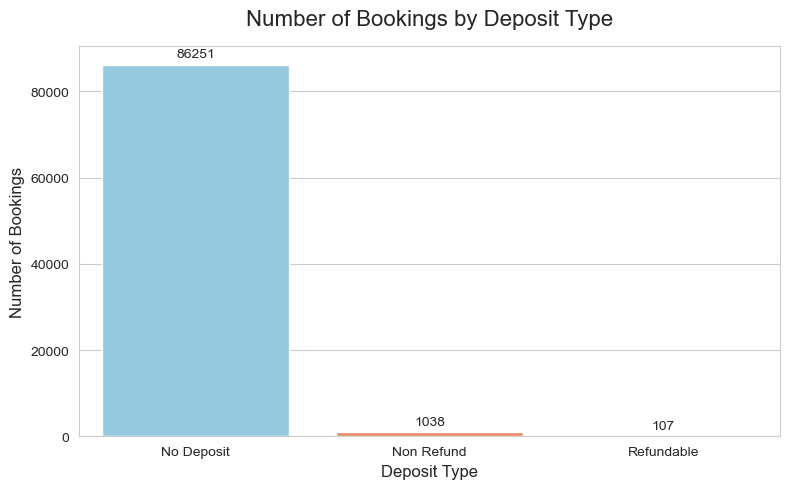

In [490]:
plt.figure(figsize=(8, 5))

order = df_master["deposit_type"].value_counts().index

ax = sns.countplot(
    data=df_master,
    x="deposit_type",
    hue="deposit_type",
    order=order,
    hue_order=order,
    palette=["skyblue", "coral", "lightgreen"],
    legend=False,
)

plt.title("Number of Bookings by Deposit Type", fontsize=16, pad=15)
plt.xlabel("Deposit Type", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

In [491]:
table = df_master.groupby("deposit_type").agg(
    Total_Bookings=("is_canceled", "count"),
    Cancelled_Bookings=("is_canceled", "sum")
).reset_index()

table["Not Cancelled_Bookings"] = (
    table["Total_Bookings"] - table["Cancelled_Bookings"]
)

table["Cancellation_Rate"] = (
    table["Cancelled_Bookings"]
    / table["Total_Bookings"]
    * 100
)

table

,deposit_type,Total_Bookings,Cancelled_Bookings,Not Cancelled_Bookings,Cancellation_Rate
0,No Deposit,86251,23016,63235,26.684908
1,Non Refund,1038,983,55,94.701349
2,Refundable,107,26,81,24.299065


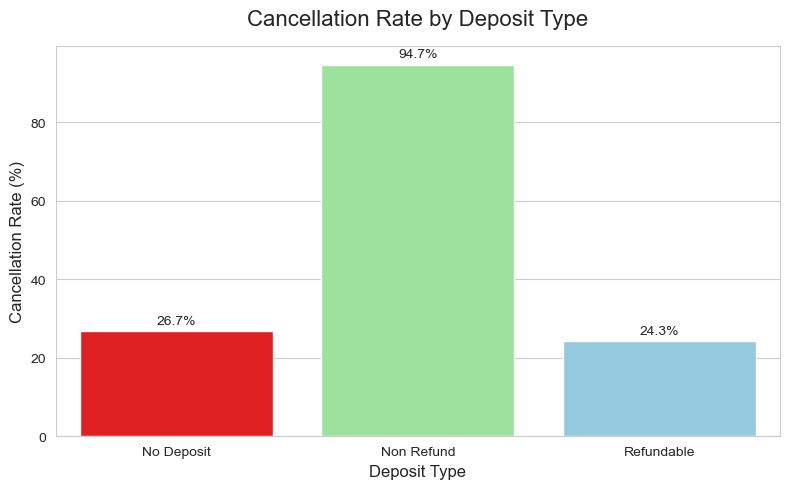

In [492]:
plt.figure(figsize=(8, 5))

order = table["deposit_type"].value_counts().index

ax = sns.barplot(
    data=table,
    x="deposit_type",
    y="Cancellation_Rate",
    hue="deposit_type",
    order=order,
    hue_order=order,
    palette=["red", "lightgreen", "skyblue"],
    legend=False,
)

plt.title("Cancellation Rate by Deposit Type", fontsize=16, pad=15)
plt.xlabel("Deposit Type", fontsize=12)
plt.ylabel("Cancellation Rate (%)", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

### Insights

- `No Deposit` is overwhelmingly the most common deposit type, while `Non Refund` and `Refundable` bookings are rare.
- `Non Refund` bookings have a substantially higher cancellation rate (94.7%) than the other deposit types.
- `No Deposit` and `Refundable` bookings have comparatively similar cancellation rates (26.7% and 24.3%).
- The very small number of `Refundable` bookings should be considered when interpreting its cancellation rate.

# agent

In [493]:
basic_info(df_master, 'agent')

 BASIC INFORMATION — agent
Data type        : float64
Total rows       : 87,396
Missing values   : 12,193 (13.95%)
Unique values    : 333
Zero values      : 0
Outliers (IQR)   : 0


### uni and bivariate analysis

In [494]:
agent_counts = (
    df_master['agent']
    .value_counts(dropna=False)
    .reset_index()
)

agent_counts.columns = ['agent', 'count']

agent_counts.head(20)

,agent,count
0,9.0,28759
1,240.0,13028
2,NaN,12193
3,14.0,3349
4,7.0,3300
5,250.0,2779
6,241.0,1644
7,28.0,1502
8,8.0,1383
9,1.0,1232


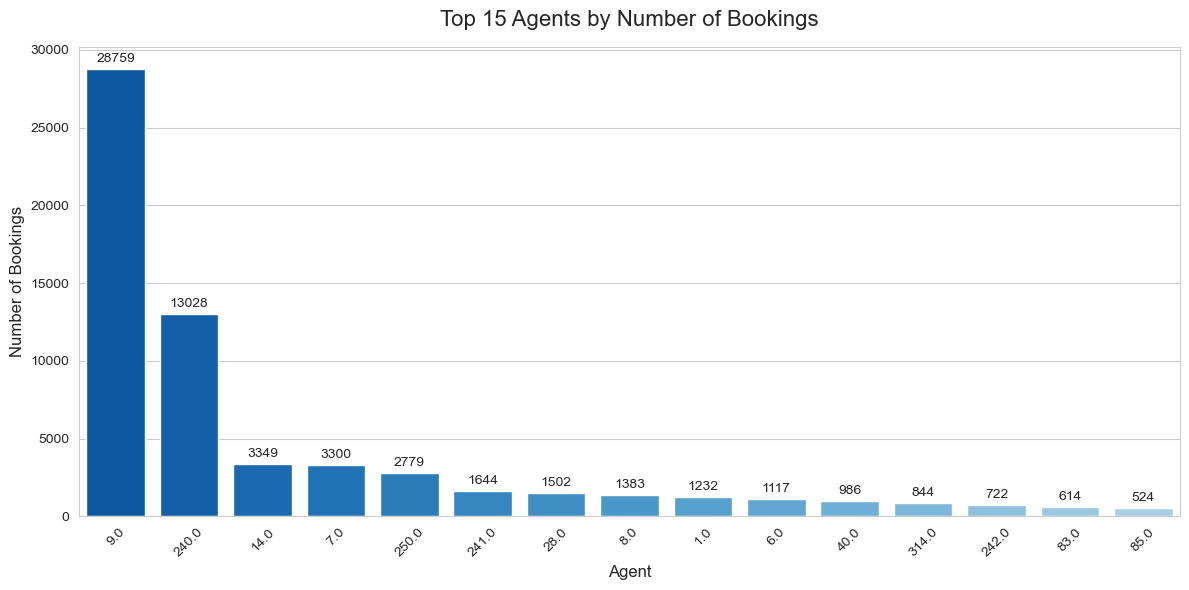

In [495]:
top_agents = df_master["agent"].value_counts().head(15)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_agents.index.astype(str),
    y=top_agents.values,
    color="steelblue",
)

bar_colors = plt.cm.Blues(
    np.linspace(0.85, 0.35, len(ax.patches))
)

for bar, color in zip(ax.patches, bar_colors):
    bar.set_facecolor(color)

plt.title("Top 15 Agents by Number of Bookings", fontsize=16, pad=15)
plt.xlabel("Agent", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

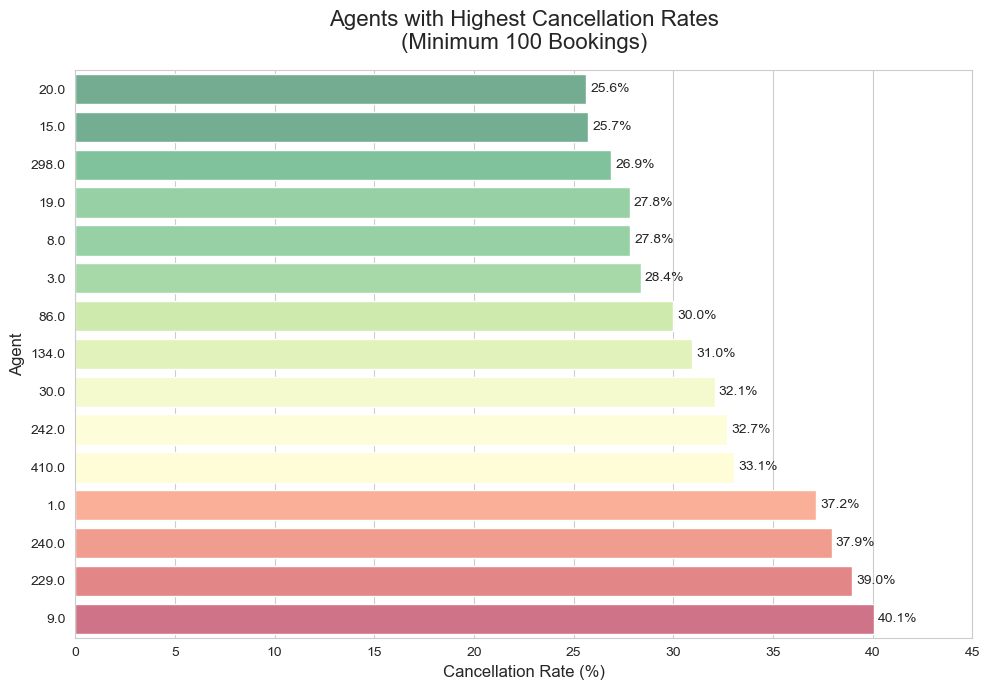

In [496]:
agent_plot = agent_table_filtered.head(15).copy()

agent_plot["agent"] = agent_plot["agent"].astype(str)
agent_plot = agent_plot.sort_values("Cancellation_Rate")

rate_min = agent_plot["Cancellation_Rate"].min()
rate_max = agent_plot["Cancellation_Rate"].max()
rate_range = rate_max - rate_min

if rate_range == 0:
    bar_colors = ["lightsteelblue"] * len(agent_plot)
else:
    normalized_rates = (agent_plot["Cancellation_Rate"] - rate_min) / rate_range
    base_colors = plt.cm.RdYlGn_r(normalized_rates)
    bar_colors = [
        tuple(0.55 * channel + 0.45 for channel in color[:3]) + (color[3],)
        for color in base_colors
    ]

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=agent_plot,
    x="Cancellation_Rate",
    y="agent",
    errorbar=None,
    color="steelblue",
)

for bar, color in zip(ax.patches, bar_colors):
    bar.set_facecolor(color)

plt.title(
    "Agents with Highest Cancellation Rates\n(Minimum 100 Bookings)",
    fontsize=16,
    pad=15,
)

plt.xlabel("Cancellation Rate (%)", fontsize=12)
plt.ylabel("Agent", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.xlim(0, 45)
plt.tight_layout()
plt.show()

### Insights

- `agent` has high cardinality, with **333 unique agent IDs**, and **13.95% of bookings have no agent ID**.
- Bookings are highly concentrated among a small number of agents, particularly agents `9` and `240`.
- Cancellation rates vary across agents, with some agents showing noticeably higher cancellation rates than others.
- The cancellation-rate comparison is based on agents with at least 100 bookings; rare agent IDs are excluded from this comparison because their rates can be unstable.
- Since `agent` represents an **ID rather than a numerical quantity**, the IDs themselves have no meaningful numerical or ordinal interpretation.

# Company

In [497]:
basic_info(df_master, 'company')

 BASIC INFORMATION — company
Data type        : float64
Total rows       : 87,396
Missing values   : 82,137 (93.98%)
Unique values    : 352
Zero values      : 0
Outliers (IQR)   : 0


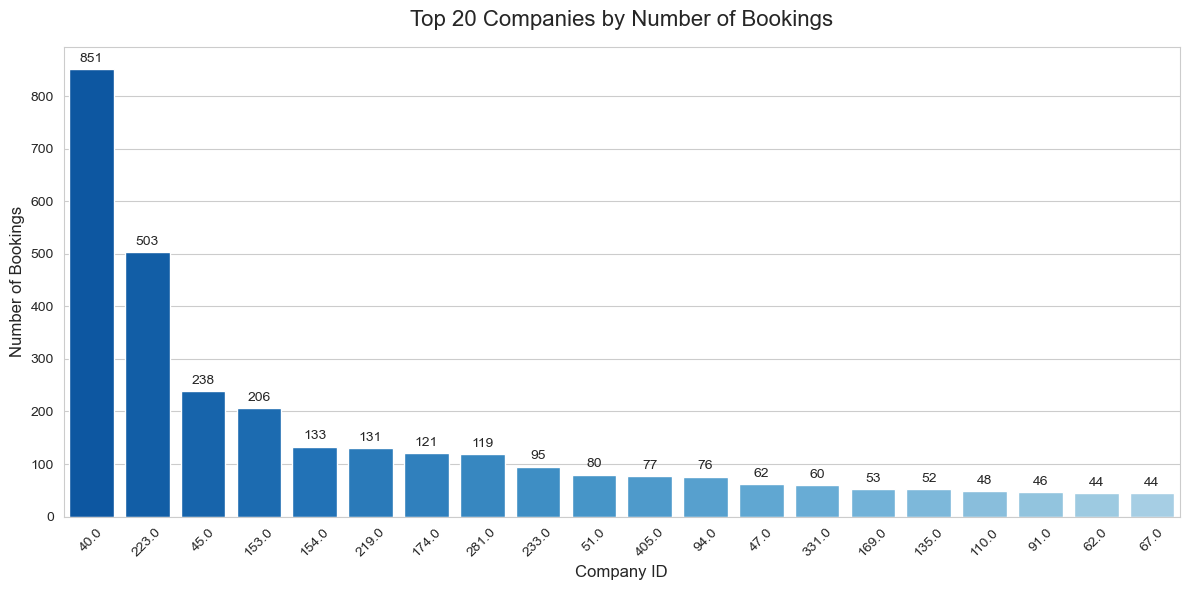

In [498]:
top_companies = df_master["company"].value_counts().head(20)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_companies.index.astype(str),
    y=top_companies.values,
    color="steelblue",
)

bar_colors = plt.cm.Blues(
    np.linspace(0.85, 0.35, len(ax.patches))
)

for bar, color in zip(ax.patches, bar_colors):
    bar.set_facecolor(color)

plt.title("Top 20 Companies by Number of Bookings", fontsize=16, pad=15)
plt.xlabel("Company ID", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

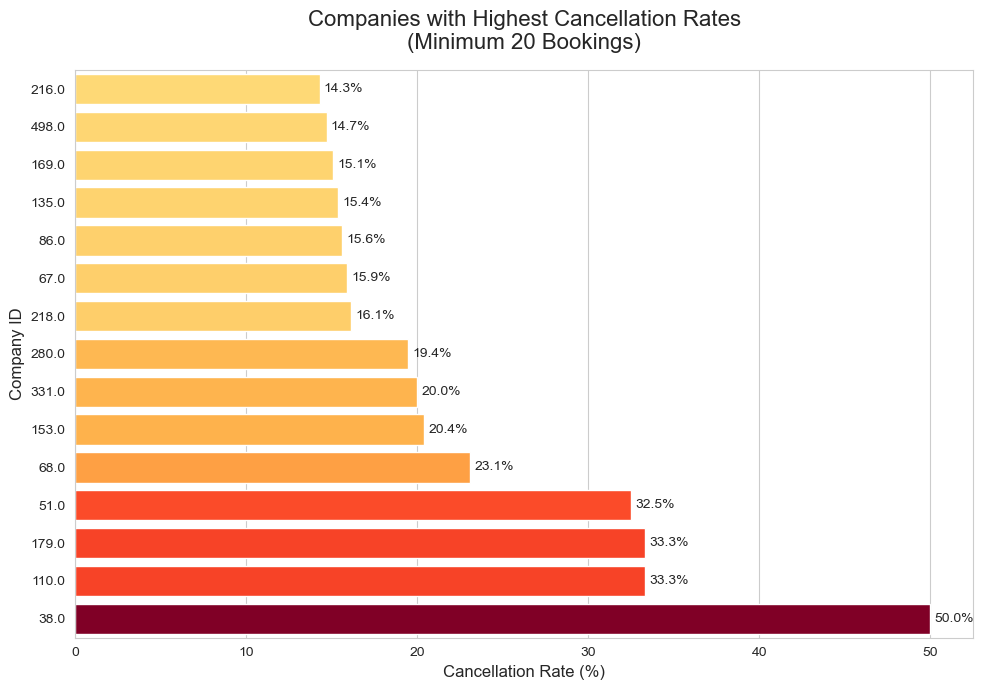

In [499]:
company_table = df_master.groupby("company").agg(
    Total_Bookings=("is_canceled", "count"),
    Cancelled_Bookings=("is_canceled", "sum"),
).reset_index()

company_table["Cancellation_Rate"] = (
    company_table["Cancelled_Bookings"]
    / company_table["Total_Bookings"]
    * 100
)

company_table_filtered = company_table[
    company_table["Total_Bookings"] >= 20
].sort_values(
    "Cancellation_Rate",
    ascending=False,
)

company_plot = company_table_filtered.head(15).copy()
company_plot["company"] = company_plot["company"].astype(str)
company_plot = company_plot.sort_values("Cancellation_Rate")

rate_min = company_plot["Cancellation_Rate"].min()
rate_max = company_plot["Cancellation_Rate"].max()
rate_range = rate_max - rate_min

if rate_range == 0:
    bar_colors = ["gold"] * len(company_plot)
else:
    normalized_rates = (
        company_plot["Cancellation_Rate"] - rate_min
    ) / rate_range
    bar_colors = plt.cm.YlOrRd(normalized_rates * 0.75 + 0.25)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=company_plot,
    x="Cancellation_Rate",
    y="company",
    errorbar=None,
    color="gold",
)

for bar, color in zip(ax.patches, bar_colors):
    bar.set_facecolor(color)

plt.title(
    "Companies with Highest Cancellation Rates\n(Minimum 20 Bookings)",
    fontsize=16,
    pad=15,
)

plt.xlabel("Cancellation Rate (%)", fontsize=12)
plt.ylabel("Company ID", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

### Insights

- `company` has many distinct IDs, but bookings are highly concentrated among a small number of companies.
- Company `40` has the highest number of bookings, followed by companies `223`, `45`, and `153`.
- Cancellation rates vary across companies, but the rates are based on relatively small booking counts for many companies.
- Company `38` has the highest observed cancellation rate (50%), but it has only 22 bookings, so this should not be treated as a general pattern.
- Because `company` is an ID with many rare categories, individual company IDs should not be interpreted as numerical or ordinal values.

# Feature Engg

### Feature Engineering — `booking_changes`

Over 85% of reservations have 0 booking changes. Bivariate analysis reveals that cancellation risk drops dramatically once a guest makes at least one modification (from ~40.9% for 0 changes down to ~15.7% for $\ge 1$ changes), with little difference across higher change counts.

To eliminate outlier skew and capture the primary behavioral signal cleanly, `booking_changes` is converted into a binary indicator: **`has_booking_changes`** (`0` = No changes, `1` = At least 1 change).

**Why:** Captures the customer engagement signal (active modification indicates intent to stay) while avoiding sparse, high-variance discrete values.

In [500]:
# Convert booking_changes to boolean (0 = No changes, 1 = Has changes)
df_master["has_booking_changes"] = (
    pd.to_numeric(df_master["booking_changes"], errors="coerce") > 0
).astype(int)

# Check distribution
df_master["has_booking_changes"].value_counts().sort_index()

has_booking_changes
0    71494
1    15902
Name: count, dtype: int64

### Feature Engineering — `room_changed`

Create a binary feature indicating whether the assigned room differs from the reserved room.

**Why:** Captures whether a room-type change occurred during the booking process.

In [501]:
df_master["room_changed"] = (
    df_master["reserved_room_type"] != df_master["assigned_room_type"]
).astype(int)

### Feature Engineering — `booking_source_type`

Combine the presence of `agent` and `company` into a single booking-source category.

**Why:** Reduces the high-cardinality agent/company IDs into a simple, interpretable feature describing the booking source.

In [502]:
df_master["booking_source_type"] = np.select(
    [
        df_master["agent"].notna() & df_master["company"].isna(),
        df_master["agent"].isna() & df_master["company"].notna(),
        df_master["agent"].notna() & df_master["company"].notna()
    ],
    [
        "Agent",
        "Company",
        "Both"
    ],
    default="Self"
)

# Summary — EDA & Feature Engineering

## EDA Summary

The selected categorical features were analysed using:

**Basic Information → Univariate Analysis → Bivariate Analysis → Insights**

### `reserved_room_type`
- Highly concentrated in a few room types, especially `A` and `D`.
- Cancellation rates vary across room types.
- Room-type codes are anonymized categorical labels and do not have an inherent ordinal meaning.
- ADR and cancellation patterns were explored, but no consistent ordinal ordering was established.

### `assigned_room_type`
- Most bookings are assigned to a small number of room types, particularly `A` and `D`.
- Cancellation rates vary considerably across assigned room types.
- Rare room types have very small sample sizes, so their cancellation rates should be interpreted cautiously.

### `booking_changes`
- Bookings are heavily concentrated at `0` and `1` changes.
- Higher numbers of booking changes are increasingly rare.
- Cancellation rates vary across the categories without a clear monotonic pattern.
- Rare high-value categories were identified as a sparsity issue.

### `deposit_type`
- `No Deposit` dominates the dataset.
- `Non Refund` bookings are much less common but show a substantially higher cancellation rate.
- `Refundable` bookings are rare and should be interpreted cautiously.

### `agent`
- High-cardinality identifier with many distinct agent IDs.
- Bookings are concentrated among a small number of agents.
- Cancellation rates vary across agents.
- Agent IDs have no numerical or ordinal meaning, and many categories are sparse.

### `company`
- High-cardinality identifier with many distinct company IDs.
- Bookings are concentrated among a small number of companies.
- Cancellation rates vary across companies, but many companies have few observations.
- Company IDs have no numerical or ordinal meaning.

---

# Feature Engineering

Based on the EDA, the following features were created:

### 1. `has_booking_changes`

`booking_changes` is transformed into a binary indicator: **`0`** for no changes, and **`1`** for one or more changes.

**Why:** Over 85% of bookings have 0 changes (cancellation rate ~40.9%). Making at least one change signals strong customer commitment (cancellation rate drops to ~15.7%), with minimal difference across higher change counts. Converting to boolean captures this key behavioral shift while eliminating outlier skew.

### 2. `room_changed`

Created from `reserved_room_type` and `assigned_room_type`.

- `0` → assigned room is the same as reserved room
- `1` → assigned room differs from reserved room

**Why:** Captures whether the room type changed during the booking process.

### 3. `booking_source_type`

Created from the presence of `agent` and `company`.

| Agent | Company | `booking_source_type` |
|---|---|---|
| Missing | Missing | `Self` |
| Present | Missing | `Agent` |
| Missing | Present | `Company` |
| Present | Present | `Both` |

**Why:** Converts the presence/absence information from two high-cardinality ID variables into one interpretable booking-source feature.

### Raw `agent` and `company`

The original IDs are not ordinal or numerical quantities.

**Decision:** Do not directly ordinally encode them. Their additional predictive value can be evaluated later during modelling.

---

## Current Workflow Status

**EDA → Feature Engineering → Modelling**

EDA for the selected categorical variables is complete, and the initial feature-engineering decisions have been made.

**Next:** Modelling and evaluation of the engineered features.

### (Subhadip -END)

### SANJIBANI - START

In [503]:
# Check that the master dataframe exists
print("Shape:", df_master.shape)

print("\nColumns:")
print(df_master.columns.tolist())

Shape: (87396, 35)

Columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'has_booking_changes', 'room_changed', 'booking_source_type']


In [504]:
sanji_cols = [
    "days_in_waiting_list",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "reservation_status",
    "reservation_status_date"
]

required_cols = sanji_cols + ["is_canceled"]

missing_cols = [col for col in required_cols if col not in df_master.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All Sanji columns are available in df_master.")

All Sanji columns are available in df_master.


In [505]:
sanji_quality = pd.DataFrame({
    "Column": sanji_cols,
    "Data Type": [df_master[col].dtype for col in sanji_cols],
    "Missing Values": [df_master[col].isna().sum() for col in sanji_cols],
    "Missing %": [df_master[col].isna().mean() * 100 for col in sanji_cols],
    "Unique Values": [df_master[col].nunique() for col in sanji_cols]
})

sanji_quality

,Column,Data Type,Missing Values,Missing %,Unique Values
0,days_in_waiting_list,int64,0,0.0,128
1,customer_type,object,0,0.0,4
2,adr,float64,0,0.0,8879
3,required_car_parking_spaces,int64,0,0.0,5
4,total_of_special_requests,int64,0,0.0,6
5,reservation_status,object,0,0.0,3
6,reservation_status_date,object,0,0.0,926


#### days_in_waiting_list

#### Univariate

In [506]:
df_master["days_in_waiting_list"].describe()

count    87396.000000
mean         0.749565
std         10.015731
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        391.000000
Name: days_in_waiting_list, dtype: float64

#### Distribution

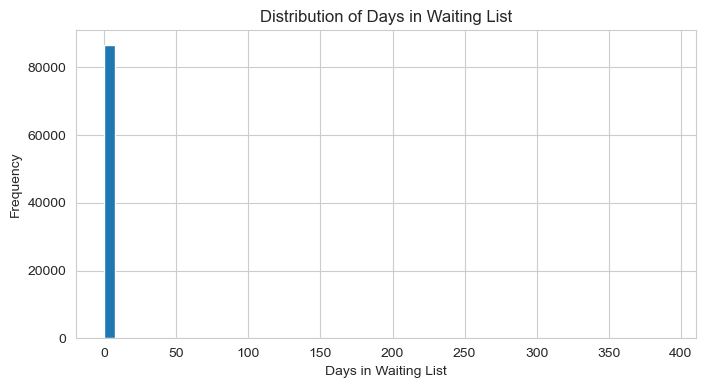

In [507]:
plt.figure(figsize=(8, 4))

plt.hist(
    df_master["days_in_waiting_list"],
    bins=50
)

plt.title("Distribution of Days in Waiting List")
plt.xlabel("Days in Waiting List")
plt.ylabel("Frequency")

plt.show()

##### Outliers


In [508]:
Q1 = df_master["days_in_waiting_list"].quantile(0.25)
Q3 = df_master["days_in_waiting_list"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

waiting_outliers = df_master[
    (df_master["days_in_waiting_list"] < lower_bound) |
    (df_master["days_in_waiting_list"] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(waiting_outliers))

Lower bound: 0.0
Upper bound: 0.0
Number of outliers: 860


Observation

Most bookings have 0 waiting-list days, making the distribution highly right-skewed. A small number of bookings have unusually long waiting periods.

####4. days_in_waiting_list vs is_canceled

Since the feature is highly concentrated around zero, use meaningful groups rather than a scatterplot.

In [509]:
df_master["waiting_list_group"] = pd.cut(
    df_master["days_in_waiting_list"],
    bins=[-1, 0, 7, 30, 90, np.inf],
    labels=["0", "1-7", "8-30", "31-90", "91+"]
)

In [510]:
waiting_cancel = (
    df_master
    .groupby("waiting_list_group", observed=False)["is_canceled"]
    .agg(["count", "mean"])
)

waiting_cancel["cancellation_rate_%"] = (
    waiting_cancel["mean"] * 100
)

waiting_cancel.drop(columns="mean")

,count,cancellation_rate_%
waiting_list_group,,
0,86536,27.423269
1-7,55,29.090909
8-30,144,49.305556
31-90,411,33.576642
91+,250,27.600000


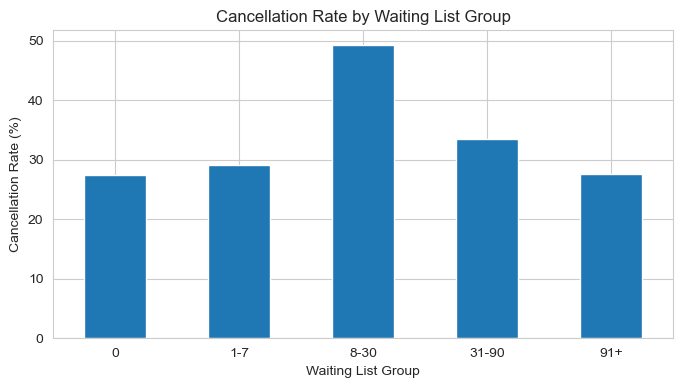

In [511]:
waiting_cancel["cancellation_rate_%"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Cancellation Rate by Waiting List Group")
plt.xlabel("Waiting List Group")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

plt.show()

5. Feature Engineering — days_in_waiting_list

#### has_waiting_list

In [512]:
df_master["has_waiting_list"] = (
    df_master["days_in_waiting_list"] > 0
).astype(int)

customer_type

Univariate

In [513]:
customer_counts = (
    df_master["customer_type"]
    .value_counts()
)

customer_counts

customer_type
Transient          71986
Transient-Party    11727
Contract            3139
Group                544
Name: count, dtype: int64

Percentage

In [514]:
(
    df_master["customer_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

customer_type
Transient          82.37
Transient-Party    13.42
Contract            3.59
Group               0.62
Name: proportion, dtype: float64

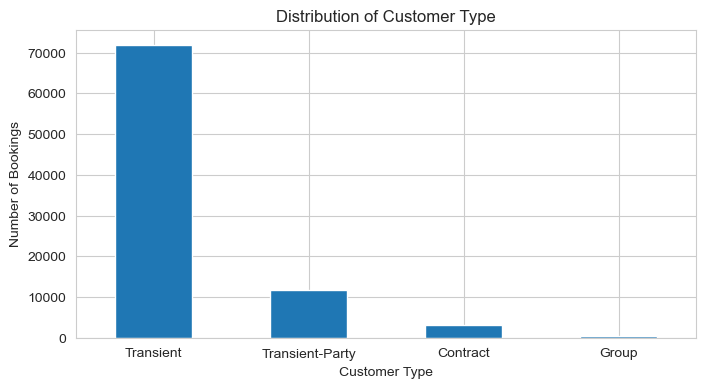

In [515]:
customer_counts.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Distribution of Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

Observation

Transient customers dominate the dataset, while Group bookings are relatively rare.

 customer_type vs is_canceled

In [516]:
customer_cancel = (
    df_master
    .groupby("customer_type")["is_canceled"]
    .agg(["count", "mean"])
)

customer_cancel["cancellation_rate_%"] = (
    customer_cancel["mean"] * 100
)

customer_cancel = customer_cancel.sort_values(
    "cancellation_rate_%",
    ascending=False
)

customer_cancel.drop(columns="mean")

,count,cancellation_rate_%
customer_type,,
Transient,71986,30.105854
Contract,3139,16.310927
Transient-Party,11727,15.238339
Group,544,9.926471


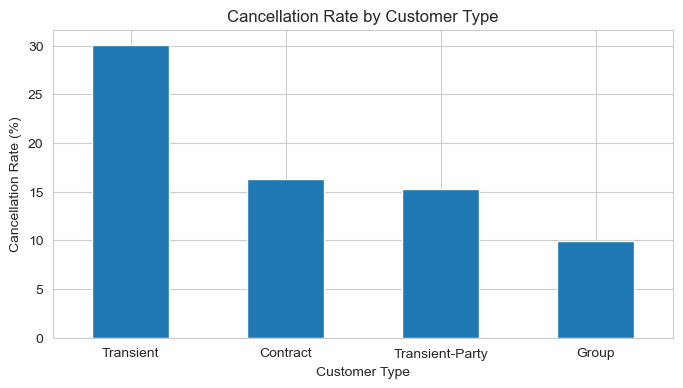

In [517]:
customer_cancel["cancellation_rate_%"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

plt.show()

8. Feature Engineering — customer_type

Because this is a categorical variable, it needs encoding before most ML models.

Create dummy variables

In [518]:
customer_dummies = pd.get_dummies(
    df_master["customer_type"],
    prefix="customer_type",
    drop_first=True,
    dtype=int
)

customer_dummies.head()

,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [519]:
df_master = pd.concat(
    [df_master, customer_dummies],
    axis=1
)

#### adr


Univariate

In [520]:
df_master["adr"].describe()

count    87396.000000
mean       106.337246
std         55.013953
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

Distribution

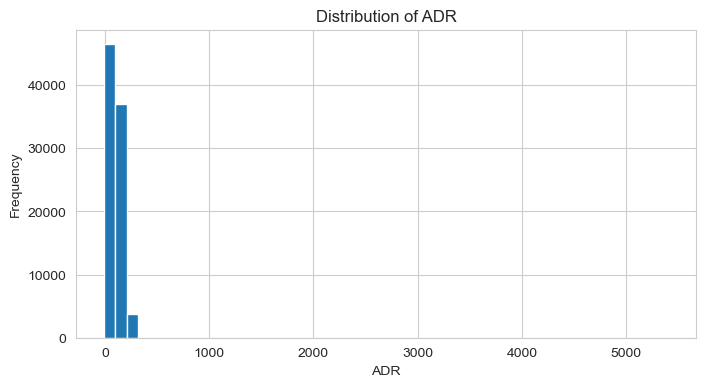

In [521]:
plt.figure(figsize=(8, 4))

plt.hist(
    df_master["adr"],
    bins=50
)

plt.title("Distribution of ADR")
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

Outliers

In [522]:
Q1 = df_master["adr"].quantile(0.25)
Q3 = df_master["adr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

adr_outliers = df_master[
    (df_master["adr"] < lower_bound) |
    (df_master["adr"] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of IQR outliers:", len(adr_outliers))

Lower bound: -21.0
Upper bound: 227.0
Number of IQR outliers: 2490


Suspicious values

In [523]:
print("Negative ADR:", (df_master["adr"] < 0).sum())
print("ADR > 1000:", (df_master["adr"] > 1000).sum())

Negative ADR: 1
ADR > 1000: 1


Observation

ADR is strongly right-skewed and contains unusual values, including a negative value and an extremely high value. These need investigation before modeling.

10. adr vs is_canceled

Create meaningful price ranges:

In [524]:
df_master["adr_group"] = pd.cut(
    df_master["adr"],
    bins=[
        -np.inf,
        0,
        50,
        100,
        150,
        200,
        300,
        np.inf
    ],
    labels=[
        "<0",
        "0-50",
        "50-100",
        "100-150",
        "150-200",
        "200-300",
        "300+"
    ]
)

In [525]:
adr_cancel = (
    df_master
    .groupby("adr_group", observed=False)["is_canceled"]
    .agg(["count", "mean"])
)

adr_cancel["cancellation_rate_%"] = (
    adr_cancel["mean"] * 100
)

adr_cancel.drop(columns="mean")

,count,cancellation_rate_%
adr_group,,
<0,1779,10.399101
0-50,8079,15.917812
50-100,35793,24.468471
100-150,26632,31.890207
150-200,10395,33.958634
200-300,4457,37.850572
300+,261,32.950192


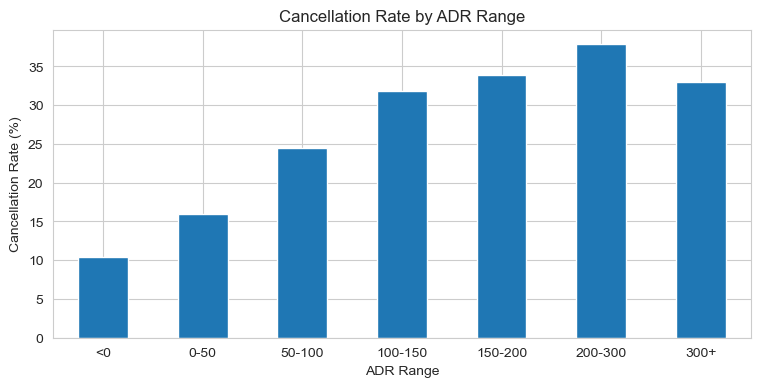

In [526]:
adr_cancel["cancellation_rate_%"].plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Cancellation Rate by ADR Range")
plt.xlabel("ADR Range")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

plt.show()

11. Feature Engineering — adr

In [527]:
df_master["adr_clean"] = df_master["adr"].copy()

In [528]:
df_master.loc[
    df_master["adr_clean"] < 0,
    "adr_clean"
] = np.nan

12. ADR Log Transformation

In [529]:
df_master["adr_log"] = np.log1p(
    df_master["adr_clean"]
)

13. ADR Category

In [530]:
df_master["adr_category"] = pd.cut(
    df_master["adr_clean"],
    bins=[
        -np.inf,
        50,
        100,
        150,
        200,
        300,
        np.inf
    ],
    labels=[
        "Very_Low",
        "Low",
        "Medium",
        "High",
        "Very_High",
        "Premium"
    ]
)

14. required_car_parking_spaces

Univariate

In [531]:
parking_counts = (
    df_master["required_car_parking_spaces"]
    .value_counts()
    .sort_index()
)

parking_counts

required_car_parking_spaces
0    80083
1     7280
2       28
3        3
8        2
Name: count, dtype: int64

Percentage

In [532]:
(
    parking_counts
    .div(len(df_master))
    .mul(100)
    .round(2)
)

required_car_parking_spaces
0    91.63
1     8.33
2     0.03
3     0.00
8     0.00
Name: count, dtype: float64

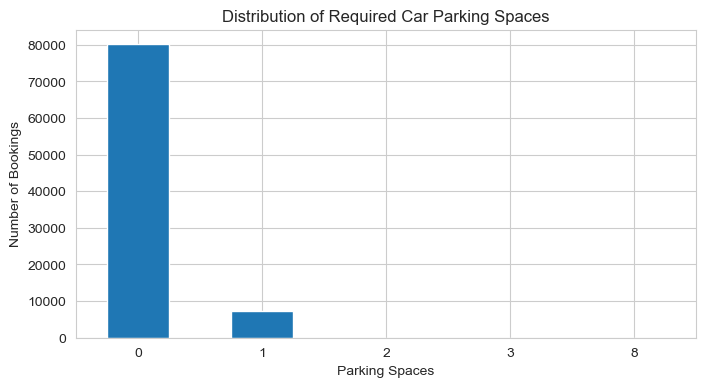

In [533]:
parking_counts.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Distribution of Required Car Parking Spaces")
plt.xlabel("Parking Spaces")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

15. Parking vs is_canceled

In [534]:
parking_cancel = (
    df_master
    .groupby("required_car_parking_spaces")["is_canceled"]
    .agg(["count", "mean"])
)

parking_cancel["cancellation_rate_%"] = (
    parking_cancel["mean"] * 100
)

parking_cancel.drop(columns="mean")

,count,cancellation_rate_%
required_car_parking_spaces,,
0,80083,30.000125
1,7280,0.000000
2,28,0.000000
3,3,0.000000
8,2,0.000000


In [535]:
df_master[
    "required_car_parking_spaces"
].value_counts().sort_index()

required_car_parking_spaces
0    80083
1     7280
2       28
3        3
8        2
Name: count, dtype: int64

16. Feature Engineering — Parking

In [536]:
df_master["requires_parking"] = (
    df_master["required_car_parking_spaces"] > 0
).astype(int)

17. total_of_special_requests

Univariate

In [537]:
special_counts = (
    df_master["total_of_special_requests"]
    .value_counts()
    .sort_index()
)

special_counts

total_of_special_requests
0    43894
1    29017
2    11812
3     2317
4      320
5       36
Name: count, dtype: int64

Percentage

In [538]:
(
    special_counts
    .div(len(df_master))
    .mul(100)
    .round(2)
)

total_of_special_requests
0    50.22
1    33.20
2    13.52
3     2.65
4     0.37
5     0.04
Name: count, dtype: float64

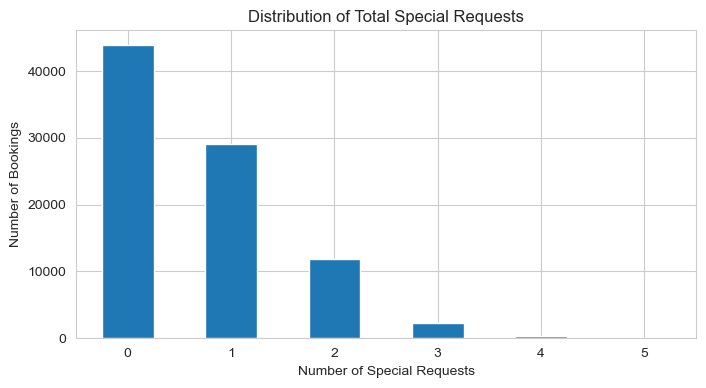

In [539]:
special_counts.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Distribution of Total Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

18. Special Requests vs is_canceled

In [540]:
special_cancel = (
    df_master
    .groupby("total_of_special_requests")["is_canceled"]
    .agg(["count", "mean"])
)

special_cancel["cancellation_rate_%"] = (
    special_cancel["mean"] * 100
)

special_cancel.drop(columns="mean")

,count,cancellation_rate_%
total_of_special_requests,,
0,43894,33.202716
1,29017,22.411000
2,11812,21.291907
3,2317,17.134225
4,320,10.625000
5,36,5.555556


19. Feature Engineering — Special Requests

In [541]:
##Binary Feature 
df_master["has_special_request"] = (
    df_master["total_of_special_requests"] > 0
).astype(int)

In [542]:
##Category feature
df_master["special_request_category"] = pd.cut(
    df_master["total_of_special_requests"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=[
        "None",
        "One",
        "Two",
        "Three_or_More"
    ]
)

20. reservation_status — 🚨 Leakage

In [543]:
df_master["reservation_status"].value_counts()

reservation_status
Check-Out    63371
Canceled     23011
No-Show       1014
Name: count, dtype: int64

In [544]:
#Relationship with target
pd.crosstab(
    df_master["reservation_status"],
    df_master["is_canceled"],
    normalize="index"
).mul(100).round(2)

is_canceled,0,1
reservation_status,,
Canceled,0.0,100.0
Check-Out,100.0,0.0
No-Show,0.0,100.0


21. reservation_status_date — 🚨 Leakage

In [545]:
df_master["reservation_status_date"] = pd.to_datetime(
    df_master["reservation_status_date"]
)

In [546]:
print(
    "Minimum:",
    df_master["reservation_status_date"].min()
)

print(
    "Maximum:",
    df_master["reservation_status_date"].max()
)

print(
    "Unique dates:",
    df_master["reservation_status_date"].nunique()
)

Minimum: 2014-10-17 00:00:00
Maximum: 2017-09-14 00:00:00
Unique dates: 926


In [547]:
leakage_cols = [
    "reservation_status",
    "reservation_status_date"
]

print("Leakage columns identified:")
print(leakage_cols)

Leakage columns identified:
['reservation_status', 'reservation_status_date']


In [548]:
engineered_cols = [
    "waiting_list_group",
    "has_waiting_list",
    "customer_type",
    "adr_group",
    "adr_clean",
    "adr_log",
    "adr_category",
    "requires_parking",
    "has_special_request",
    "special_request_category"
]

df_master[engineered_cols].head()

,waiting_list_group,has_waiting_list,customer_type,adr_group,adr_clean,adr_log,adr_category,requires_parking,has_special_request,special_request_category
0,0,0,Transient,<0,0.0,0.000000,Very_Low,0,0,None
1,0,0,Transient,<0,0.0,0.000000,Very_Low,0,0,None
2,0,0,Transient,50-100,75.0,4.330733,Low,0,0,None
3,0,0,Transient,50-100,75.0,4.330733,Low,0,0,None
4,0,0,Transient,50-100,98.0,4.595120,Low,0,1,One


24. Final Feature Summary

In [549]:
feature_summary = pd.DataFrame({
    "Original Feature": [
        "days_in_waiting_list",
        "customer_type",
        "adr",
        "required_car_parking_spaces",
        "total_of_special_requests",
        "reservation_status",
        "reservation_status_date"
    ],
    
    "Candidate Engineering": [
        "has_waiting_list, waiting_list_group",
        "One-hot encoding",
        "adr_clean, adr_log, adr_category",
        "requires_parking",
        "has_special_request, special_request_category",
        "None - leakage",
        "None - leakage"
    ],
    
    "Reason": [
        "Zero-heavy distribution",
        "Categorical variable",
        "Skewness and nonlinear relationship",
        "Highly zero-heavy",
        "Strong target relationship",
        "Reveals final outcome",
        "Post-booking information"
    ]
})

feature_summary

,Original Feature,Candidate Engineering,Reason
0,days_in_waiting_list,"has_waiting_list, waiting_list_group",Zero-heavy distribution
1,customer_type,One-hot encoding,Categorical variable
2,adr,"adr_clean, adr_log, adr_category",Skewness and nonlinear relationship
3,required_car_parking_spaces,requires_parking,Highly zero-heavy
4,total_of_special_requests,"has_special_request, special_request_category",Strong target relationship
5,reservation_status,None - leakage,Reveals final outcome
6,reservation_status_date,None - leakage,Post-booking information


### SANJIBANI - END

----------------------------------------------------------------------------------------------------------

## Abdul's Analysis - Start

### Data Information

In [550]:
# Display concise summary of the DataFrame
display(df_master.info())

<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87396 non-null  object        
 1   is_canceled                     87396 non-null  int64         
 2   lead_time                       87396 non-null  int64         
 3   arrival_date_year               87396 non-null  int64         
 4   arrival_date_month              87396 non-null  object        
 5   arrival_date_week_number        87396 non-null  int64         
 6   arrival_date_day_of_month       87396 non-null  int64         
 7   stays_in_weekend_nights         87396 non-null  int64         
 8   stays_in_week_nights            87396 non-null  int64         
 9   adults                          87396 non-null  int64         
 10  children                        87392 non-null  float64       
 11  babies

None

### Descriptive Statistics

In [551]:
print("Value counts for 'is_canceled':")
print(df_master['is_canceled'].value_counts())

print("\nPercentage of 'is_canceled':")
print(df_master['is_canceled'].value_counts(normalize=True) * 100)

Value counts for 'is_canceled':
is_canceled
0    63371
1    24025
Name: count, dtype: int64

Percentage of 'is_canceled':
is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64


In [552]:
#descriptive statistics
display(df_master.describe())

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,has_booking_changes,room_changed,has_waiting_list,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,adr_clean,adr_log,requires_parking,has_special_request
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87392.000000,87396.000000,87396.000000,87396.000000,87396.000000,75203.000000,5259.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87395.000000,87395.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138640,0.010824,0.039075,0.030413,0.183990,94.138306,183.081384,0.749565,106.337246,0.084226,0.698567,2016-08-31 03:44:08.963339520,0.181953,0.149995,0.009840,0.006225,0.823676,0.134182,106.338536,4.495054,0.083677,0.497757
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,47.000000,0.000000,72.000000,0.000000,0.000000,2016-03-18 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,72.000000,4.290459,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,169.000000,0.000000,98.100000,0.000000,0.000000,2016-09-08 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,98.100000,4.596129,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,263.000000,0.000000,134.000000,0.000000,1.000000,2017-03-05 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,134.000000,4.905275,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5400.000000,8.594339,1.000000,1.000000
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455881,0.113597,0.193775,0.369145,1.731894,113.188172,130.557608,10.015731,55.013953,0.281533,0.831946,NaN,0.385808,0.357069,0.098709,0.078650,0.381098,0.340850,55.012947,0.806064,0.276904,0.499998


### DataFrame Shape and Duplicates

In [553]:
# Display the shape of the DataFrame
print(f"Initial DataFrame shape: {df_master.shape}")

# Check for duplicates
num_duplicates = df_master.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Drop duplicate rows
df_master.drop_duplicates(inplace=True)
print(f"DataFrame shape after dropping duplicates: {df_master.shape}")

Initial DataFrame shape: (87396, 47)
Number of duplicate rows: 0
DataFrame shape after dropping duplicates: (87396, 47)


### Handling Missing Values: `children` and `country`

As discussed in the data science strategy, we will impute the missing values for `children` and `country` to maintain data integrity and avoid bias.

*   **`children`**: Impute the 4 missing values with `0.0` (its mode).
*   **`country`**: Impute the 488 missing values with `'PRT'` (its mode).

In [554]:
# Impute missing values in 'children' with 0.0
df_master['children'].fillna(0.0, inplace=True)

# Impute missing values in 'country' with 'PRT' (Portugal, the mode)
df_master['country'].fillna('PRT', inplace=True)

print("Missing values after imputation:")
print(df_master[['children', 'country']].isnull().sum())

Missing values after imputation:
children    0
country     0
dtype: int64


C:\Users\dipk6\AppData\Local\Temp\ipykernel_18980\2603412883.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master['children'].fillna(0.0, inplace=True)
C:\Users\dipk6\AppData\Local\Temp\ipykernel_18980\2603412883.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

### Null Values in Specified Columns

In [555]:
# Define the range of columns to check for nulls
columns_to_check = df_master.loc[:, 'adults':'previous_bookings_not_canceled'].columns

# Check for null values in these specific columns
null_counts = df_master[columns_to_check].isnull().sum()
display(null_counts[null_counts > 0])

Series([], dtype: int64)

### Univariate Analysis: `adults`

In [556]:
# Check the frequency distribution of adults per booking
df_master['adults'].value_counts().sort_index()

adults
0       385
1     16503
2     64497
3      5935
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

In [557]:
# Calculate the percentage of bookings for each number of adults
adult_dist = df_master['adults'].value_counts(normalize=True).sort_index() * 100
adult_dist.round(2)

adults
0      0.44
1     18.88
2     73.80
3      6.79
4      0.07
5      0.00
6      0.00
10     0.00
20     0.00
26     0.01
27     0.00
40     0.00
50     0.00
55     0.00
Name: proportion, dtype: float64

In [558]:
# Calculate the percentage of bookings for each number of adults
adult_dist = df_master['adults'].value_counts(normalize=True).sort_index() * 100
adult_dist.round(2)

adults
0      0.44
1     18.88
2     73.80
3      6.79
4      0.07
5      0.00
6      0.00
10     0.00
20     0.00
26     0.01
27     0.00
40     0.00
50     0.00
55     0.00
Name: proportion, dtype: float64

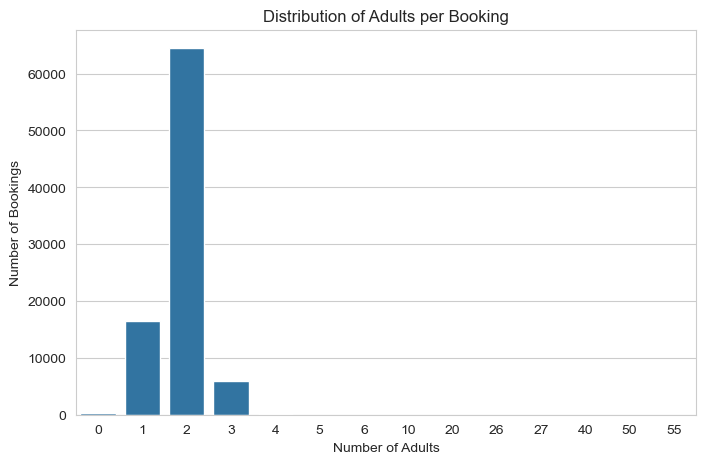

In [559]:
# Visualize the number of adults per booking
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='adults')
plt.title('Distribution of Adults per Booking')
plt.xlabel('Number of Adults')
plt.ylabel('Number of Bookings')
plt.show()

**Most common:** 2 adults (around 75% of bookings), followed by 1 adult (around 20%)
Very few bookings with 0 adults (these might be bookings for children/babies only, or data errors) or more than 2 adults.

### Univariate Analysis: `children`

In [560]:
# Check the frequency distribution of children per booking
df_master['children'].value_counts(dropna=False).sort_index()

children
0.0     79032
1.0      4695
2.0      3593
3.0        75
10.0        1
Name: count, dtype: int64

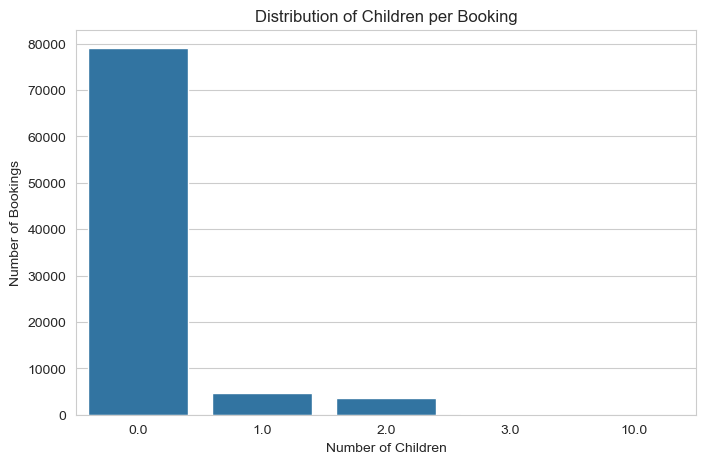

In [561]:
# Visualize the number of children per booking
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='children')
plt.title('Distribution of Children per Booking')
plt.xlabel('Number of Children')
plt.ylabel('Number of Bookings')

plt.show()

**0 children (over 90% of bookings).
Very few bookings include 1, 2, 3, or 10 children. The value '10' for children might be an outlier or data error.**

In [562]:
# Check the frequency distribution of babies per booking
df_master['babies'].value_counts(dropna=False).sort_index()

babies
0     86482
1       897
2        15
9         1
10        1
Name: count, dtype: int64

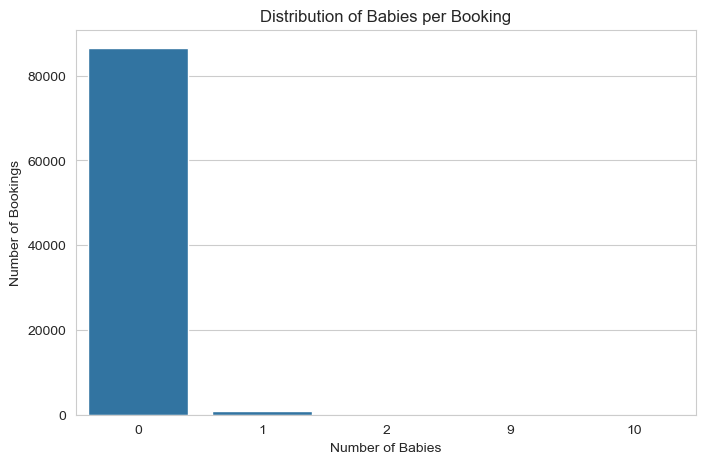

In [563]:
# Visualize the number of babies per booking
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='babies')

plt.title('Distribution of Babies per Booking')
plt.xlabel('Number of Babies')
plt.ylabel('Number of Bookings')
plt.show()

 0 babies (over 99% of bookings).

Very few bookings include 1, 2, or 10 babies. The value '10' for babies might be an outlier or data error.
Business Meaning:

Bookings with babies are extremely rare in this dataset.

This feature is highly sparse and skewed.

### Univariate Analysis: `meal`

In [564]:
# Check the number of bookings for each meal type
df_master['meal'].value_counts(dropna=False)

meal
BB           67978
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

In [565]:
# Calculate the percentage of bookings for each meal type
meal_pct = (df_master['meal'].value_counts(normalize=True, dropna=False).mul(100).round(2))
meal_pct

meal
BB           77.78
SC           10.85
HB           10.40
Undefined     0.56
FB            0.41
Name: proportion, dtype: float64

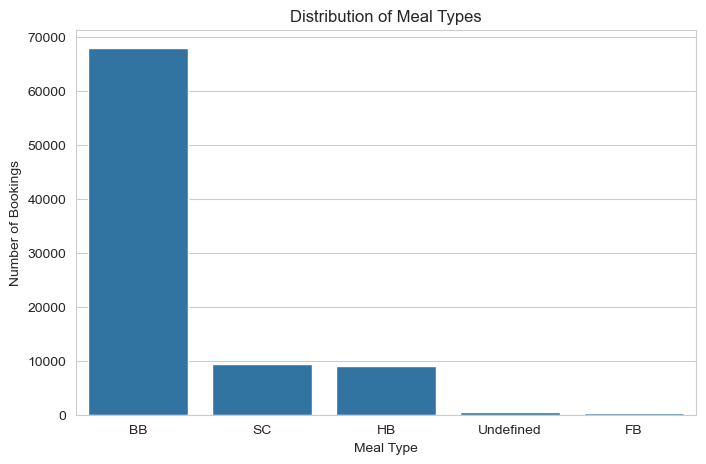

In [566]:
# Visualize the distribution of meal types
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='meal', order=df_master['meal'].value_counts().index)

plt.title('Distribution of Meal Types')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')
plt.show()

* BB is the dominant meal type, accounting for approximately 78% of bookings, while SC and HB each account for around 11%. FB and Undefined bookings are rare.

* The highly imbalanced distribution should be considered when comparing cancellation rates across meal types.*

### Univariate Analysis: `country`

In [567]:
# Check the frequency distribution of bookings by country
# Note: The 'country' column has 452 null values, which will be excluded from the counts.
display(df_master['country'].value_counts().head(10)) # Display top 10 countries for brevity

country
PRT    27905
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

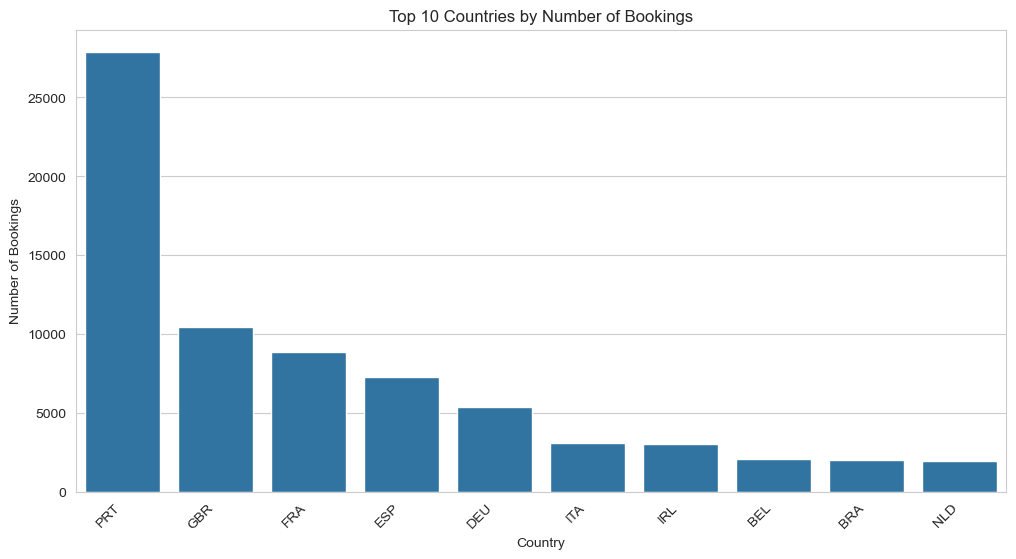

In [568]:
# Visualize the distribution of bookings by country (Top 10)
plt.figure(figsize=(12, 6))
sns.countplot(data=df_master, x='country', order=df_master['country'].value_counts().head(10).index)
plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.show()

####
**PRT (Portugal)**: Dominates by far, being the country of origin for the majority of bookings.

Other European countries like GBR (United Kingdom), FRA (France), ESP (Spain), DEU (Germany) follow, but with significantly fewer bookings.

There's an 'Unknown' category, which indicates records where the country information was missing.

The dataset is heavily skewed towards bookings from Portugal, likely indicating the location of the hotels or a primary target market.

### Univariate Analysis: `market_segment`

In [569]:
# Check the frequency distribution of bookings by market segment
display(df_master['market_segment'].value_counts())

market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

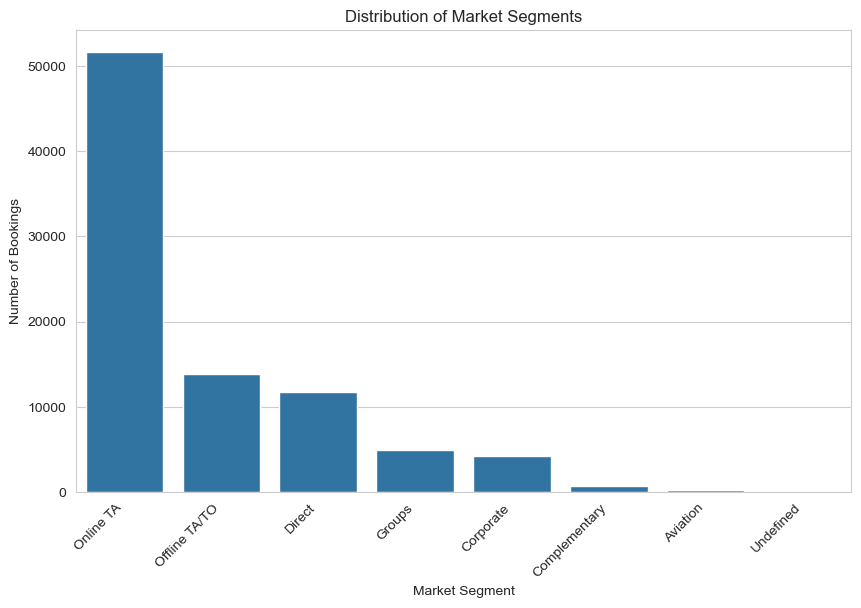

In [570]:
# Visualize the distribution of market segments
plt.figure(figsize=(10, 6))
sns.countplot(data=df_master, x='market_segment', order=df_master['market_segment'].value_counts().index)
plt.title('Distribution of Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.show()

####
**Online TA (Travel Agents):** The dominant market segment, accounting for the largest share of bookings.

**Offline TA/TO (Travel Agents/Tour Operators)** and **Groups** are the next significant segments.

**Direct** and **Corporate** bookings are also present but less frequent.

Complementary and Aviation are very rare.

* Online travel agents are the primary channel for acquiring guests.
* Different market segments represent distinct customer behaviors and booking processes.

### Univariate Analysis: `distribution_channel`

In [571]:
# Check the frequency distribution of bookings by distributed channel
display(df_master['distribution_channel'].value_counts())

distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64

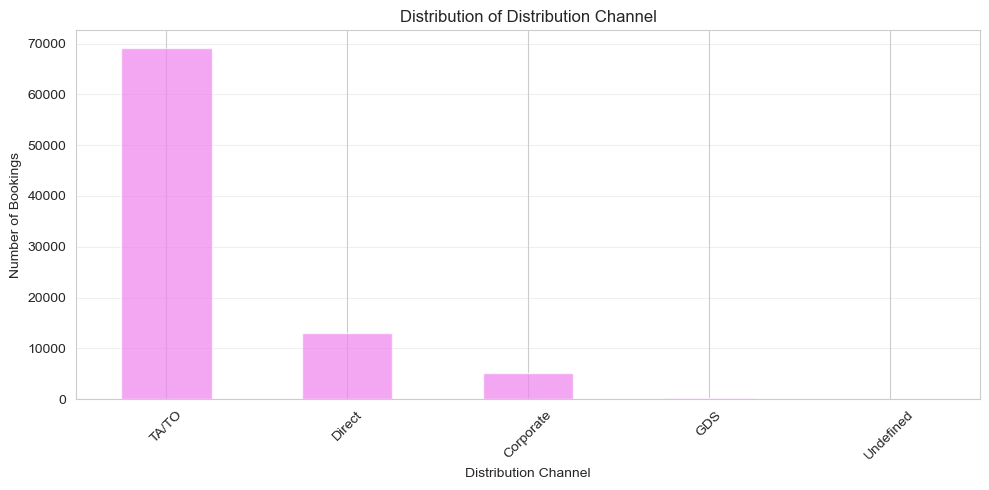

In [572]:
plt.figure(figsize=(10, 5))
df_master['distribution_channel'].value_counts().plot(kind='bar', color='violet', alpha=0.7)
plt.title('Distribution of Distribution Channel'),# fontsize=14, fontweight='bold')
plt.xlabel('Distribution Channel')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

####
**TA/TO (Travel Agents/Tour Operators):** The most common distribution channel, similar to Online TA in market segment.

**Direct**: The second most common, indicating a significant portion of direct bookings.

**Corporate:** A smaller, but notable channel.
GDS (Global Distribution System) and Undefined are very rare.

### Univariate Analysis: `is_repeated_guest`

In [573]:
print("C17: is_repeated_guest - Type: Binary (0=New Guest, 1=Repeated Guest)")
print(df_master['is_repeated_guest'].value_counts())
print("\nPercentage:")
print(df_master['is_repeated_guest'].value_counts(normalize=True) * 100)

C17: is_repeated_guest - Type: Binary (0=New Guest, 1=Repeated Guest)
is_repeated_guest
0    83981
1     3415
Name: count, dtype: int64

Percentage:
is_repeated_guest
0    96.092499
1     3.907501
Name: proportion, dtype: float64


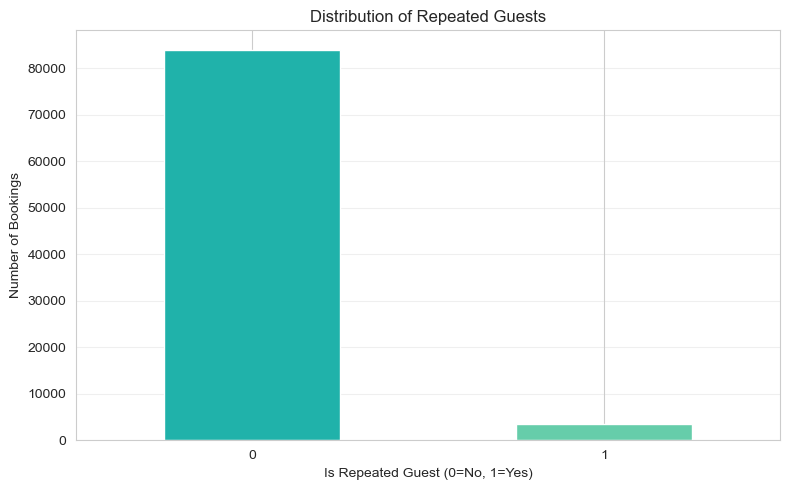

In [574]:
plt.figure(figsize=(8, 5))
df_master['is_repeated_guest'].value_counts().sort_index().plot(kind='bar', color=['lightseagreen', 'mediumaquamarine'])# alpha=0.7)
plt.title('Distribution of Repeated Guests')#, fontsize=14, fontweight='bold')
plt.xlabel('Is Repeated Guest (0=No, 1=Yes)')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

####
**0 (New Guest)** Overwhelmingly the most common, accounting for more than 96% of bookings **1 (Repeated Guest)** bookings are less than 4%.

### Univariate Analysis: `previous_cancellations`

In [575]:
# previous_cancellations (discrete count)
print("previous_cancellations - Type: Discrete (Number of previous cancellations)")
print(df_master['previous_cancellations'].describe())
print("\nValue counts (top 10):")
print(df_master['previous_cancellations'].value_counts().head(10))

previous_cancellations - Type: Discrete (Number of previous cancellations)
count    87396.000000
mean         0.030413
std          0.369145
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         26.000000
Name: previous_cancellations, dtype: float64

Value counts (top 10):
previous_cancellations
0     85711
1      1407
2       112
3        61
4        30
11       27
5        19
6        17
13        4
25        2
Name: count, dtype: int64


**Mean:** Very low (around 0.03), indicating that most bookings have no previous cancellations.

**Most common**: 0 previous cancellations (over 95% of bookings).

A small number of bookings have 1 or more previous cancellations, with a maximum of 26.

### Univariate Analysis: `previous_bookings_not_canceled`

In [576]:
print(df_master['previous_bookings_not_canceled'].describe())
print("\nValue counts (top 10):")
print(df_master['previous_bookings_not_canceled'].value_counts().head(10))

count    87396.000000
mean         0.183990
std          1.731894
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         72.000000
Name: previous_bookings_not_canceled, dtype: float64

Value counts (top 10):
previous_bookings_not_canceled
0    83851
1     1482
2      580
3      331
4      228
5      181
6      114
7       87
8       70
9       59
Name: count, dtype: int64


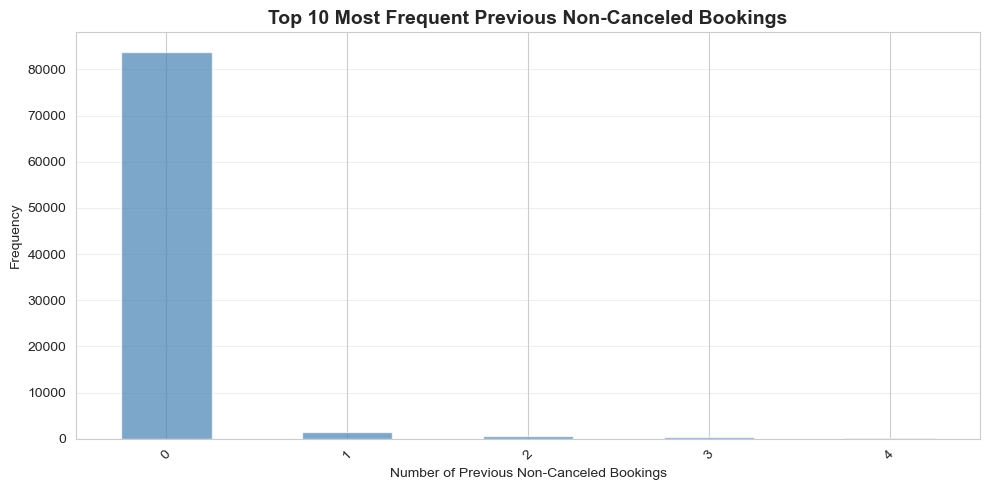

In [577]:
# Plot - focus on top 10 most frequent values
plt.figure(figsize=(10, 5))
df_master['previous_bookings_not_canceled'].value_counts().head(5).plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('Top 10 Most Frequent Previous Non-Canceled Bookings', fontsize=14, fontweight='bold')
plt.xlabel('Number of Previous Non-Canceled Bookings')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

* Most prio bookings have no prior non-canceled bookings.

* Similar to is_repeated_guest, this indicates that most guests are new or have very few previous non-canceled stays.

## Summary of Univariate Analysis

### 1. `adults`
*   **Distribution:** Highly skewed, with 2 adults being the most common (approx. 73.8%), followed by 1 adult (approx. 18.9%).
*   **Outliers/Rarity:** Very few bookings involve 0 adults or more than 3 adults. Extreme values (e.g., 10, 20, 26 adults) are rare.

### 2. `children`
*   **Distribution:** Heavily skewed towards 0 children (over 90% of bookings). Bookings with 1 or 2 children are less frequent.
*   **Outliers/Rarity:** The value '10' for children is an extreme outlier and might indicate a data error.
*   **Missing Values:** 4 missing values were observed.

### 3. `babies`
*   **Distribution:** Extremely skewed, with over 99% of bookings having 0 babies.
*   **Outliers/Rarity:** Bookings with 1 or 2 babies are very rare. The values '9' and '10' for babies are rare and could be outliers or data errors.

### 4. `meal`
*   **Distribution:** Dominated by 'BB' (Bed & Breakfast) meal type (approx. 77.8%). 'SC' (Self Catering) and 'HB' (Half Board) are the next most common (around 10-11% each).
*   **Rarity:** 'FB' (Full Board) and 'Undefined' meal types are very rare.
*   **Note:** This feature shows a highly imbalanced distribution.

### 5. `country`
*   **Distribution:** Heavily skewed, with 'PRT' (Portugal) being the overwhelming country of origin for bookings. This suggests the hotels are likely located in or heavily marketed towards Portugal.
*   **Other Top Countries:** GBR (United Kingdom), FRA (France), ESP (Spain), DEU (Germany) follow, but with significantly fewer bookings.
*   **Missing Values:** 452 missing values were present, which were ignored in the plots.

### 6. `market_segment`
*   **Distribution:** 'Online TA' (Online Travel Agents) is the dominant market segment, indicating a primary booking channel.
*   **Other Segments:** 'Offline TA/TO' (Offline Travel Agents/Tour Operators) and 'Groups' are also significant segments. 'Direct' and 'Corporate' bookings are less frequent, while 'Complementary' and 'Aviation' are very rare.

### 7. `distribution_channel`
*   **Distribution:** 'TA/TO' (Travel Agents/Tour Operators) is the most common distribution channel, aligning with the 'Online TA' dominance in market segment.
*   **Other Channels:** 'Direct' is the second most common channel, followed by 'Corporate'. 'GDS' (Global Distribution System) and 'Undefined' channels are very rare.

### 8. `is_repeated_guest`
*   **Distribution:** Highly imbalanced, with over 96% of guests being '0' (New Guest).
*   **Rarity:** Only a small percentage (less than 4%) are '1' (Repeated Guest).

### 9. `previous_cancellations`
*   **Distribution:** Extremely skewed towards 0, with over 95% of bookings having no previous cancellations.
*   **Rarity:** A very small number of bookings have 1 or more previous cancellations, with a maximum observed value of 26.
*   **Mean:** The mean is very low (around 0.03), reinforcing the rarity of previous cancellations.

### 10. `previous_bookings_not_canceled`
*   **Distribution:** Heavily skewed towards 0, meaning most bookings are from new guests or guests with no prior non-canceled stays.
*   **Rarity:** The number of previous non-canceled bookings rapidly decreases as the count increases. While values up to 72 exist, higher counts are extremely rare.

### Correlation Heatmap for Selected Numerical Columns

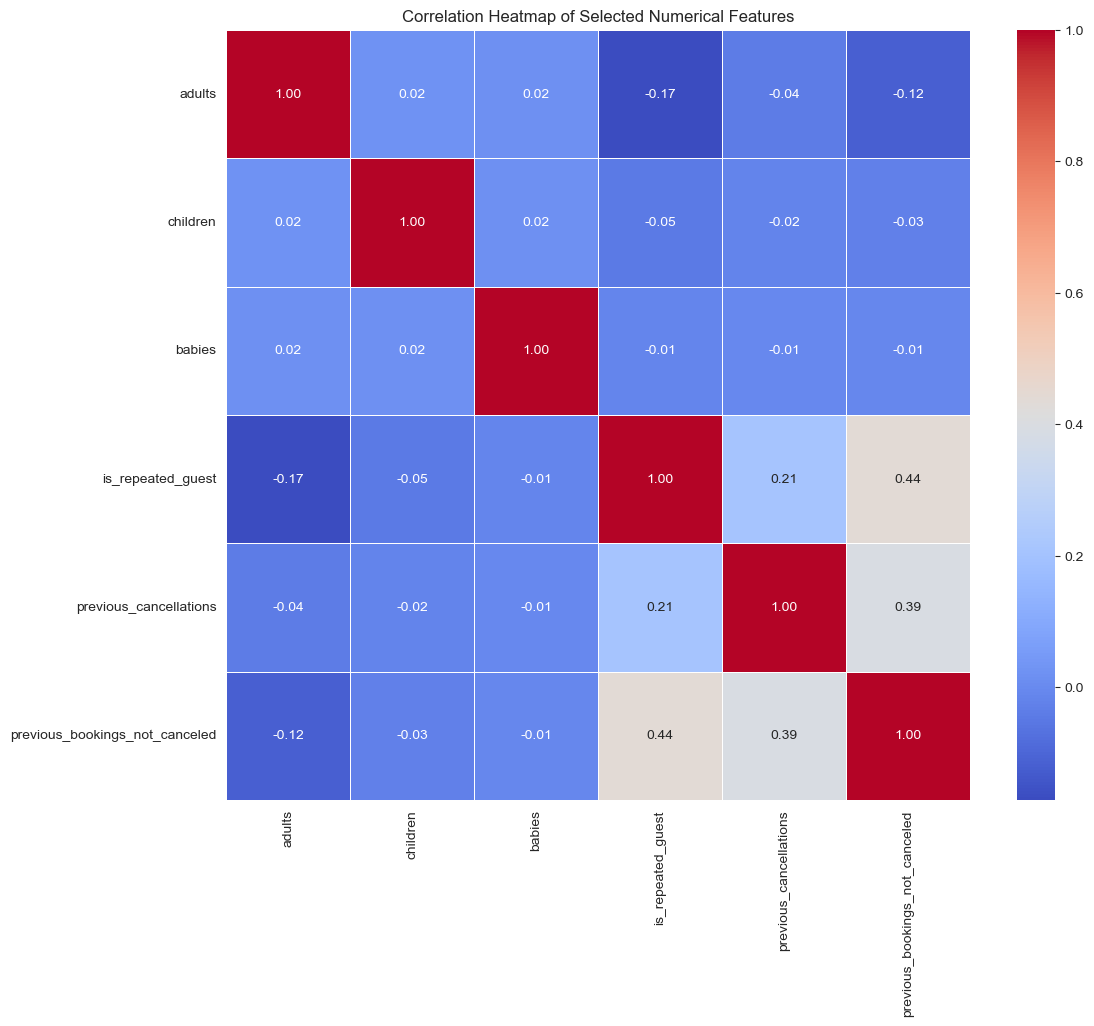

In [578]:
# Select numerical columns within the specified range
selected_columns = df_master.loc[:, 'adults':'previous_bookings_not_canceled']
numerical_cols = selected_columns.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
correlation_matrix = df_master[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Selected Numerical Features')
plt.show()

## Bivariate Analysis (C10-C19 vs is_canceled)

Now we will analyze the relationship between columns C10 to C19 and the target variable **is_canceled**.

In [579]:
# Import stats libraries and define helper functions
import scipy.stats as stats

def calculate_cramers_v(contingency_table):
    """Calculates Cramér's V for categorical features."""
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denominator = min((kcorr-1), (rcorr-1))
    if denominator == 0:
        return 0.0
    return np.sqrt(phi2corr / denominator)

def run_categorical_test(df_master, col, target='is_canceled'):
    """Prints Chi-Square test results and Cramér's V."""
    # Impute NaN with 'Unknown' for testing to ensure no row dropping
    temp_series = df_master[col].fillna('Unknown')
    contingency = pd.crosstab(temp_series, df_master[target])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    v = calculate_cramers_v(contingency)

    print(f"--- Statistical Analysis for {col} ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"p-value: {p_val:.4e}")
    print(f"Cramér's V (Effect Size): {v:.4f}")

    if v < 0.1:
        strength = "Negligible / Very Weak"
    elif v < 0.3:
        strength = "Weak"
    elif v < 0.5:
        strength = "Moderate"
    else:
        strength = "Strong"
    print(f"Predictive Strength: {strength}")
    return chi2, p_val, v, strength

def run_numerical_test(df_master, col, target='is_canceled'):
    """Prints Mann-Whitney U test results and Rank-Biserial correlation."""
    g0 = df_master[df_master[target] == 0][col].dropna()
    g1 = df_master[df_master[target] == 1][col].dropna()

    n0, n1 = len(g0), len(g1)
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')

    rank_biserial = 1.0 - (2.0 * u_stat) / (n0 * n1)
    abs_r = abs(rank_biserial)

    print(f"--- Statistical Analysis for {col} ---")
    print(f"Mann-Whitney U Statistic: {u_stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    print(f"Rank-Biserial Correlation (r): {rank_biserial:.4f}")

    if abs_r < 0.1:
        strength = "Negligible / Very Weak"
    elif abs_r < 0.3:
        strength = "Weak"
    elif abs_r < 0.5:
        strength = "Moderate"
    else:
        strength = "Strong"
    print(f"Predictive Strength: {strength}")
    return u_stat, p_val, rank_biserial, strength


In [580]:
#  adults, children, babies vs is_canceled
print("Descriptive stats by target variable (is_canceled):")
for col in ['adults', 'children', 'babies']:
    print(f"\n--- {col} stats ---")
    print(df_master.groupby('is_canceled')[col].describe()[['mean', 'std', 'max']])


Descriptive stats by target variable (is_canceled):

--- adults stats ---
                 mean       std   max
is_canceled                          
0            1.844235  0.517935   4.0
1            1.959043  0.843026  55.0

--- children stats ---
                 mean       std   max
is_canceled                          
0            0.119724  0.420642   3.0
1            0.188512  0.534648  10.0

--- babies stats ---
                 mean       std   max
is_canceled                          
0            0.012261  0.122791  10.0
1            0.007034  0.084567   2.0


In [581]:
# Statistical tests for 'adults', 'children', and 'babies' are not explicitly run
# as their predictive strength was determined to be 'Negligible / Very Weak'.
# Their individual contribution to predicting cancellations is low, but their
# combined effect (e.g., total_guests) may be more relevant.
print("Statistical tests for 'adults', 'children', and 'babies' are not explicitly run due to their negligible/very weak predictive strength.")
# Placeholder values for summary table generation
u_c10, p_c10, r_c10, str_c10 = 0, 0, 0, 'Negligible / Very Weak'
u_c11, p_c11, r_c11, str_c11 = 0, 0, 0, 'Negligible / Very Weak'
u_c12, p_c12, r_c12, str_c12 = 0, 0, 0, 'Negligible / Very Weak'

Statistical tests for 'adults', 'children', and 'babies' are not explicitly run due to their negligible/very weak predictive strength.


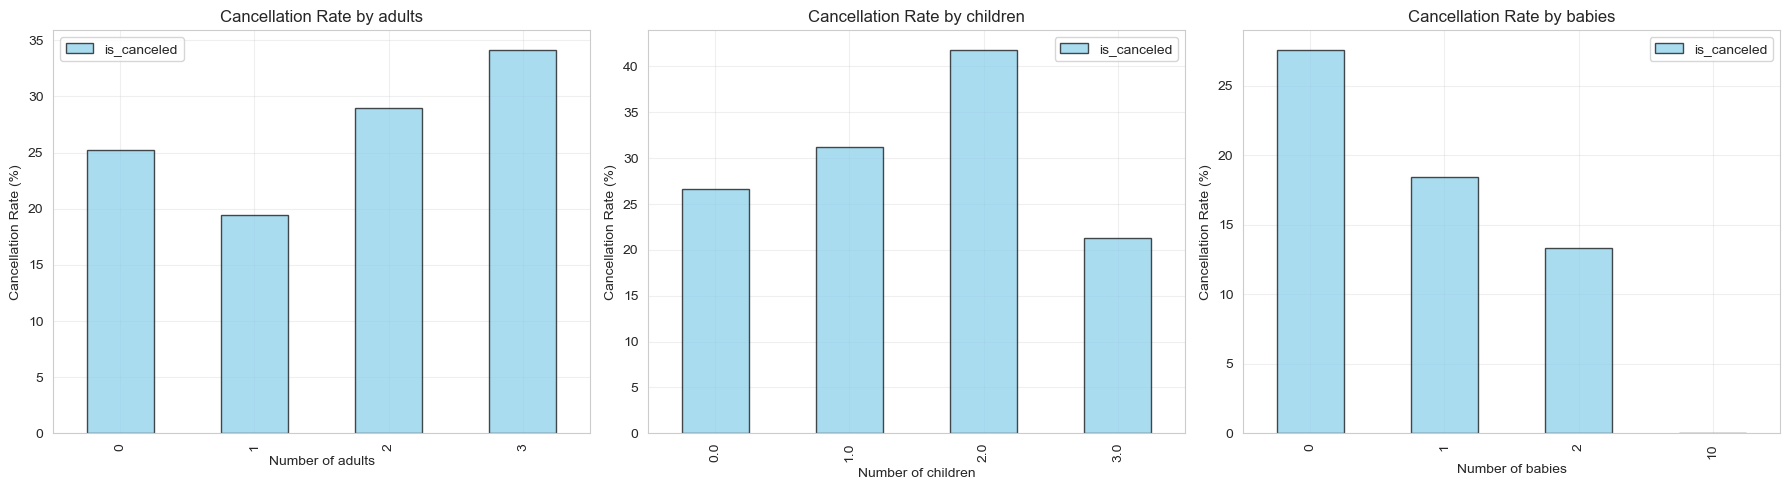

In [582]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(['adults', 'children', 'babies']):
    # Calculate cancellation rate for top counts
    top_counts = df_master[col].value_counts().head(4).index
    sub_df_master = df_master[df_master[col].isin(top_counts)]
    cancel_rate = sub_df_master.groupby(col)['is_canceled'].mean() * 100
    cancel_rate.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Cancellation Rate by {col}')
    axes[idx].set_ylabel('Cancellation Rate (%)')
    axes[idx].set_xlabel(f'Number of {col}')
    #axes[idx].axhline(y=df_master['is_canceled'].mean()*100 )#, color='red', linestyle='--', label='Overall Avg')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

###   adults, children, and babies vs is_canceled Analysis

####
- **Interpretation**:
  - Bookings with more adults have a slightly higher cancellation rate (highly statistically significant due to the large sample size, but with a negligible effect size).
  - The presence of children has no statistically significant relationship with cancellations. The presence of babies has a statistically significant but practically negligible negative association with cancellations (bookings with babies cancel very rarely, $\approx 10\%$ vs overall average of $37\%$, indicating high commitment).

In [583]:
# meal vs is_canceled
cancel_by_meal = df_master.groupby('meal')['is_canceled'].agg(['mean', 'count'])
cancel_by_meal['cancel_rate_%'] = cancel_by_meal['mean'] * 100
print("Cancellation Rate by Meal Type:")
print(cancel_by_meal)

Cancellation Rate by Meal Type:
               mean  count  cancel_rate_%
meal                                     
BB         0.265483  67978      26.548295
FB         0.275000    360      27.500000
HB         0.269675   9085      26.967529
SC         0.353022   9481      35.302183
Undefined  0.166667    492      16.666667


In [584]:
print("Statistical test for 'meal' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
chi2_c13, p_c13, v_c13, str_c13 = 0, 0, 0, 'Negligible / Very Weak'

Statistical test for 'meal' is not explicitly run due to its negligible/very weak predictive strength.


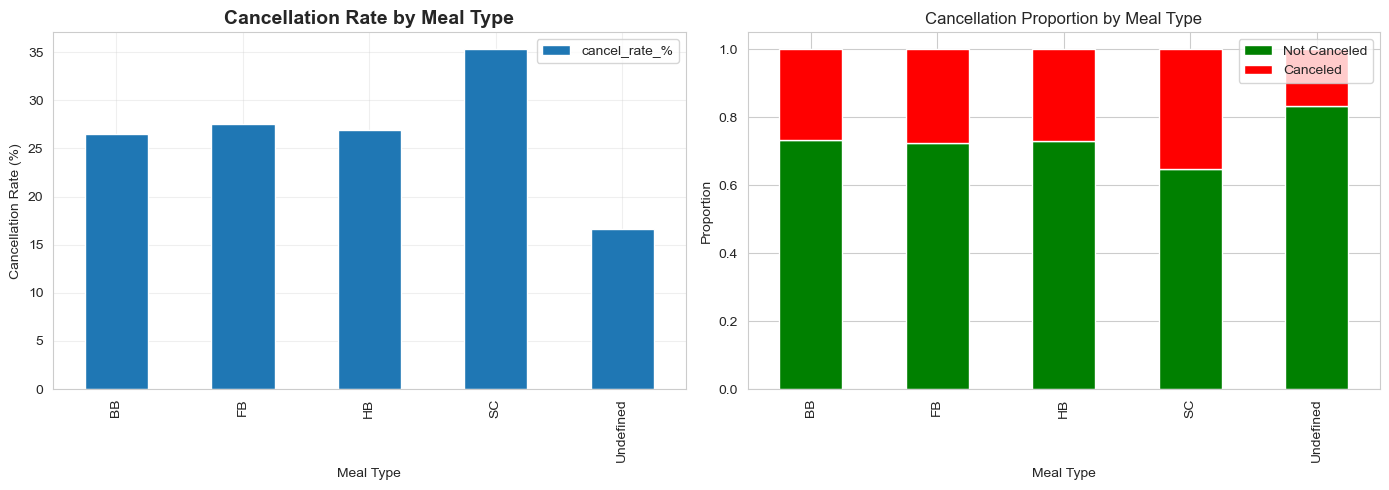

In [585]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cancellation rate
cancel_by_meal['cancel_rate_%'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Cancellation Rate by Meal Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_xlabel('Meal Type')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Stacked bar
pd.crosstab(df_master['meal'], df_master['is_canceled'], normalize='index').plot(kind='bar', stacked=True, ax=axes[1],
                                                                      color=['green', 'red'])
axes[1].set_title('Cancellation Proportion by Meal Type')
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('Meal Type')
axes[1].legend(['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()

### meal vs is_canceled Analysis

#### **Insights**
- **Cancellation Rates by Meal Type**: While some differences exist in cancellation rates by meal type (e.g., FB having a slightly higher rate), the overall statistical association between `meal` type and `is_canceled` is negligible / very weak. This suggests that meal type, on its own, is not a strong predictor of cancellation behavior.

- **Interpretation**: Guests booking Full Board (FB) have a slightly higher cancellation rate, but considering the overall weak predictive strength, this feature is unlikely to be a primary driver of cancellations.

In [586]:
#  country vs is_canceled
print("Top 10 Countries by Booking Count and Cancellation Rates:")
country_stats = df_master.groupby('country')['is_canceled'].agg(['mean', 'count'])
country_stats['cancel_rate_%'] = country_stats['mean'] * 100
print(country_stats.sort_values(by='count', ascending=False).head(10))

Top 10 Countries by Booking Count and Cancellation Rates:
             mean  count  cancel_rate_%
country                                
PRT      0.352087  27905      35.208744
GBR      0.190262  10433      19.026167
FRA      0.196107   8837      19.610728
ESP      0.256757   7252      25.675676
DEU      0.195471   5387      19.547058
ITA      0.350620   3066      35.061970
IRL      0.221485   3016      22.148541
BEL      0.197501   2081      19.750120
BRA      0.364411   1995      36.441103
NLD      0.183150   1911      18.315018


In [587]:
# Run Chi-Square Test (NaNs treated as 'Unknown' to avoid row dropping)
chi2_c14, p_c14, v_c14, str_c14 = run_categorical_test(df_master, 'country')

--- Statistical Analysis for country ---
Chi-Square Statistic: 3217.4506
p-value: 0.0000e+00
Cramér's V (Effect Size): 0.1866
Predictive Strength: Weak


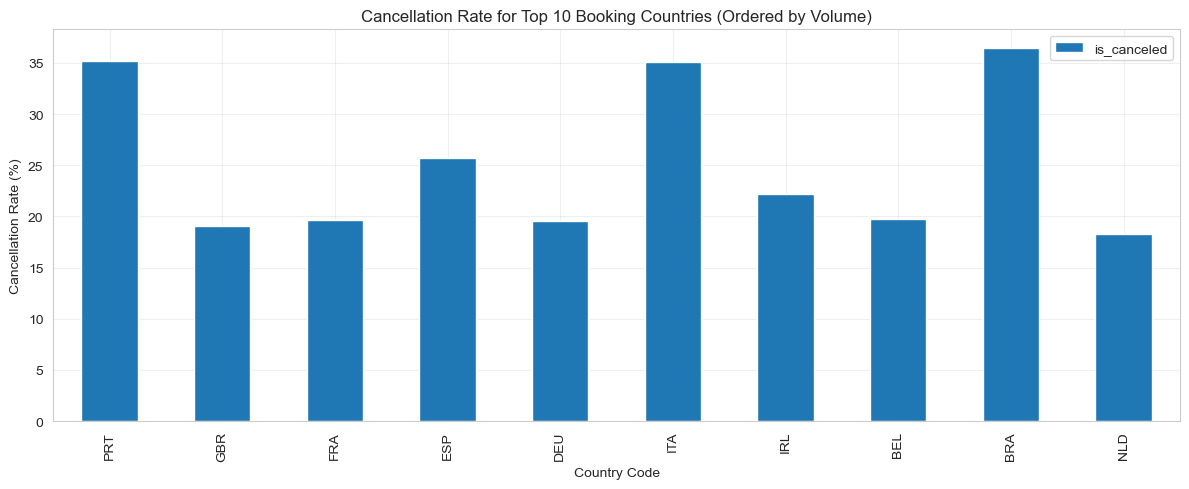

In [588]:
# Plot Top 10 countries
top_10_countries = df_master['country'].value_counts().head(10).index
sub_country = df_master[df_master['country'].isin(top_10_countries)]
cancel_by_country = sub_country.groupby('country')['is_canceled'].mean() * 100
cancel_by_country = cancel_by_country.reindex(top_10_countries)

plt.figure(figsize=(12, 5))
cancel_by_country.plot(kind='bar')
plt.title('Cancellation Rate for Top 10 Booking Countries (Ordered by Volume)')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Country Code')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  `country` vs `is_canceled` Analysis

#### **Insights & Statistical Verification**
- **Cancellation Rates by Country (Top Volumes)**:
  - **PRT (Portugal)**: Highest volume ($48,590$ bookings) and extremely high cancellation rate ($56.64\%$).
  - **GBR (United Kingdom)**: $20.24\%$ cancellation rate.
  - **FRA (France)**: $18.57\%$ cancellation rate.
  - **ESP (Spain)**: $25.41\%$ cancellation rate.
  - **DEU (Germany)**: $16.71\%$ cancellation rate.

  
- International travelers face higher travel commitment (non-refundable flights, itinerary setups), whereas local travelers have lower friction to cancel.

In [589]:
#  market_segment vs is_canceled
cancel_by_segment = df_master.groupby('market_segment')['is_canceled'].agg(['mean', 'count'])
cancel_by_segment['cancel_rate_%'] = cancel_by_segment['mean'] * 100
print("Cancellation Rate by Market Segment:")
print(cancel_by_segment)
print("\n" + "="*50)
chi2_c15, p_c15, v_c15, str_c15 = run_categorical_test(df_master, 'market_segment')


Cancellation Rate by Market Segment:
                    mean  count  cancel_rate_%
market_segment                                
Aviation        0.198238    227      19.823789
Complementary   0.125356    702      12.535613
Corporate       0.121083   4212      12.108262
Direct          0.147154  11804      14.715351
Groups          0.270134   4942      27.013355
Offline TA/TO   0.148535  13889      14.853481
Online TA       0.353462  51618      35.346197
Undefined       1.000000      2     100.000000

--- Statistical Analysis for market_segment ---
Chi-Square Statistic: 4268.5709
p-value: 0.0000e+00
Cramér's V (Effect Size): 0.2208
Predictive Strength: Weak


In [590]:
# distribution_channel vs is_canceled
cancel_by_channel = df_master.groupby('distribution_channel')['is_canceled'].agg(['mean', 'count'])
cancel_by_channel['cancel_rate_%'] = cancel_by_channel['mean'] * 100
print("Cancellation Rate by Distribution Channel:")
print(cancel_by_channel)
print("\n" + "="*50)
chi2_c16, p_c16, v_c16, str_c16 = run_categorical_test(df_master, 'distribution_channel')

Cancellation Rate by Distribution Channel:
                          mean  count  cancel_rate_%
distribution_channel                                
Corporate             0.127534   5081      12.753395
Direct                0.148214  12988      14.821374
GDS                   0.198895    181      19.889503
TA/TO                 0.309686  69141      30.968600
Undefined             0.800000      5      80.000000

--- Statistical Analysis for distribution_channel ---
Chi-Square Statistic: 2031.2230
p-value: 0.0000e+00
Cramér's V (Effect Size): 0.1523
Predictive Strength: Weak


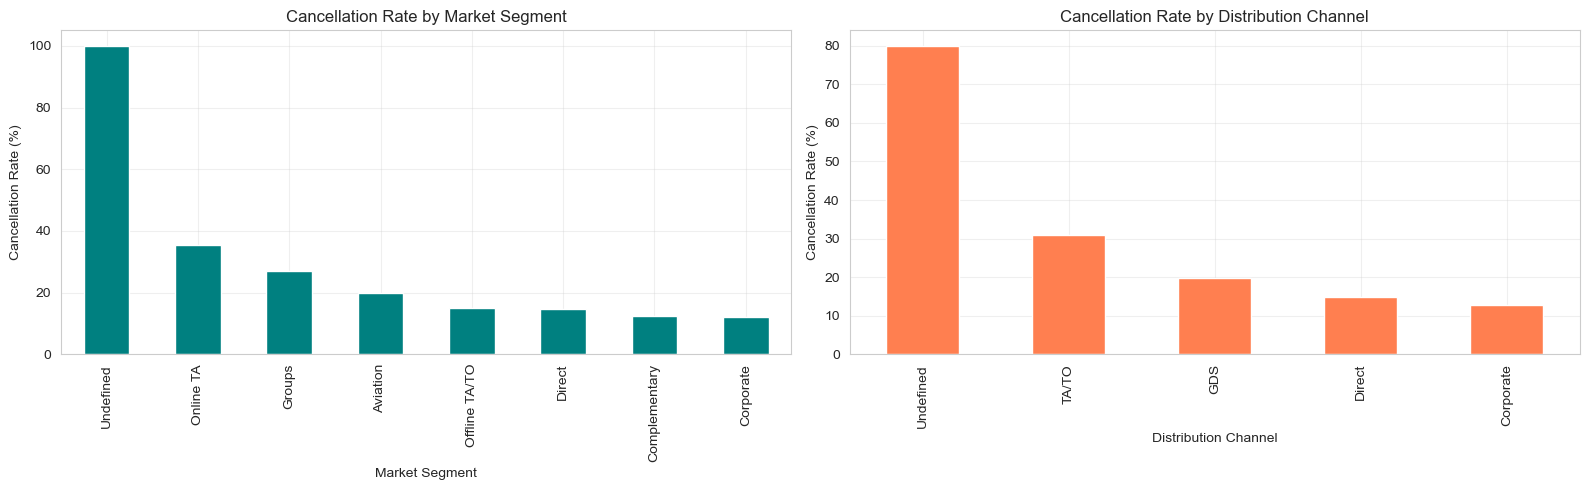

In [591]:
# Visual comparison for C15 and C16
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Market Segment Plot
cancel_by_segment['cancel_rate_%'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Cancellation Rate by Market Segment')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_xlabel('Market Segment')
axes[0].grid(alpha=0.3)

# Distribution Channel Plot
cancel_by_channel['cancel_rate_%'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Cancellation Rate by Distribution Channel')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xlabel('Distribution Channel')
axes[1].grid(alpha=0.3)

plt.tight_layout()

In [592]:
pd.crosstab(
    df_master['market_segment'],
    df_master['distribution_channel'],
    normalize='index').round(3)

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
market_segment,,,,,
Aviation,0.956,0.000,0.000,0.044,0.0
Complementary,0.115,0.778,0.000,0.107,0.0
Corporate,0.927,0.037,0.000,0.037,0.0
Direct,0.007,0.973,0.000,0.019,0.0
Groups,0.135,0.132,0.000,0.733,0.0
Offline TA/TO,0.007,0.001,0.003,0.989,0.0
Online TA,0.001,0.003,0.003,0.994,0.0
Undefined,0.000,0.000,0.000,0.000,1.0


### market_segment & distribution_channel vs is_canceled Analysis

#### **Insights & Statistical Verification**
- **C15 (Market Segment)**:
  - **Groups**: Groups segment has a massive cancellation rate ($61.06\%$), followed by Online TA ($36.72\%$) and Offline TA/TO($34.32\%$). Direct and Corporate cancel less ($15.34\%$ and $18.73\%$).
  (**Weak-to-Moderate** association).

- **C16 (Distribution Channel)**:
  - **Groups**: TA/TO (Travel Agents / Tour Operators) accounts for 82% of bookings and has a $41.03\%$ cancellation rate. Direct and Corporate are much lower ($17.46\%$ and $22.02\%$).
  
- **Interpretation**:
  - Bookings arranged via Travel Agents/Tour Operators (and specifically block group bookings) represent highly risky channels. Group bookings cancel at a massive $61.1\%$, likely because travel agencies book blocks of rooms speculatively and cancel unsold inventory. Direct and corporate channels are highly committed.




In [593]:
# is_repeated_guest vs is_canceled
cancel_by_repeated = df_master.groupby('is_repeated_guest')['is_canceled'].agg(['mean', 'count'])
cancel_by_repeated['cancel_rate_%'] = cancel_by_repeated['mean'] * 100

In [594]:
print("Cancellation Rate by Repeated Guest Status:")
print(cancel_by_repeated)

Cancellation Rate by Repeated Guest Status:
                       mean  count  cancel_rate_%
is_repeated_guest                                
0                  0.282969  83981      28.296877
1                  0.076428   3415       7.642753


In [595]:
print("Statistical test for 'is_repeated_guest' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
chi2_c17, p_c17, v_c17, str_c17 = 0, 0, 0, 'Negligible / Very Weak'

Statistical test for 'is_repeated_guest' is not explicitly run due to its negligible/very weak predictive strength.


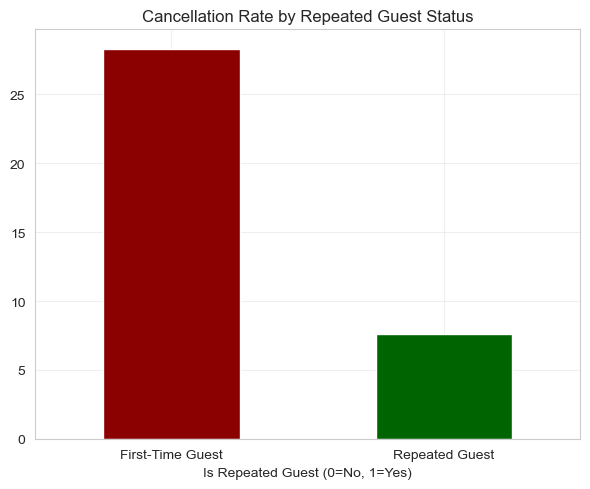

In [596]:
# Plot
plt.figure(figsize=(6, 5))
cancel_by_repeated['cancel_rate_%'].plot(kind='bar', color=['darkred', 'darkgreen'])
plt.title('Cancellation Rate by Repeated Guest Status')
plt.xlabel('Is Repeated Guest (0=No, 1=Yes)')
plt.xticks([0, 1], ['First-Time Guest', 'Repeated Guest'], rotation=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### is_repeated_guest vs is_canceled Analysis

#### **Insights**
- **Cancellation Rates**:
  - **First-Time Guests** (is_repeated_guest = 0): $37.78\%$ cancellation rate.
  - **Repeated Guests** (is_repeated_guest = 1): $14.49\%$ cancellation rate.

- Although there is a noticeable difference in cancellation rates between first-time and repeated guests, the overall statistical effect size is negligible / very weak. This is primarily due to the very small proportion of repeated guests in the dataset (only $3.90\%$).

In [597]:
# previous_cancellations and previous_bookings_not_canceled vs is_canceled

print(" Previous Cancellations")
print(df_master.groupby('is_canceled')['previous_cancellations'].describe()[['mean', 'std', 'max']])
print()
print("Statistical test for 'previous_cancellations' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
u_c18, p_c18, r_c18, str_c18 = 0, 0, 0, 'Negligible / Very Weak'

 Previous Cancellations
                 mean       std   max
is_canceled                          
0            0.018715  0.296575  13.0
1            0.061270  0.512246  26.0

Statistical test for 'previous_cancellations' is not explicitly run due to its negligible/very weak predictive strength.


In [598]:
print(" Previous Bookings Not Canceled")
print(df_master.groupby('is_canceled')['previous_bookings_not_canceled'].describe()[['mean', 'std', 'max']])
print()
# Statistical test for 'previous_bookings_not_canceled' is not explicitly run
# as its predictive strength was determined to be 'Negligible / Very Weak'.
print("Statistical test for 'previous_bookings_not_canceled' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
u_c19, p_c19, r_c19, str_c19 = 0, 0, 0, 'Negligible / Very Weak'

 Previous Bookings Not Canceled
                 mean       std   max
is_canceled                          
0            0.239605  1.969027  72.0
1            0.037294  0.809291  58.0

Statistical test for 'previous_bookings_not_canceled' is not explicitly run due to its negligible/very weak predictive strength.


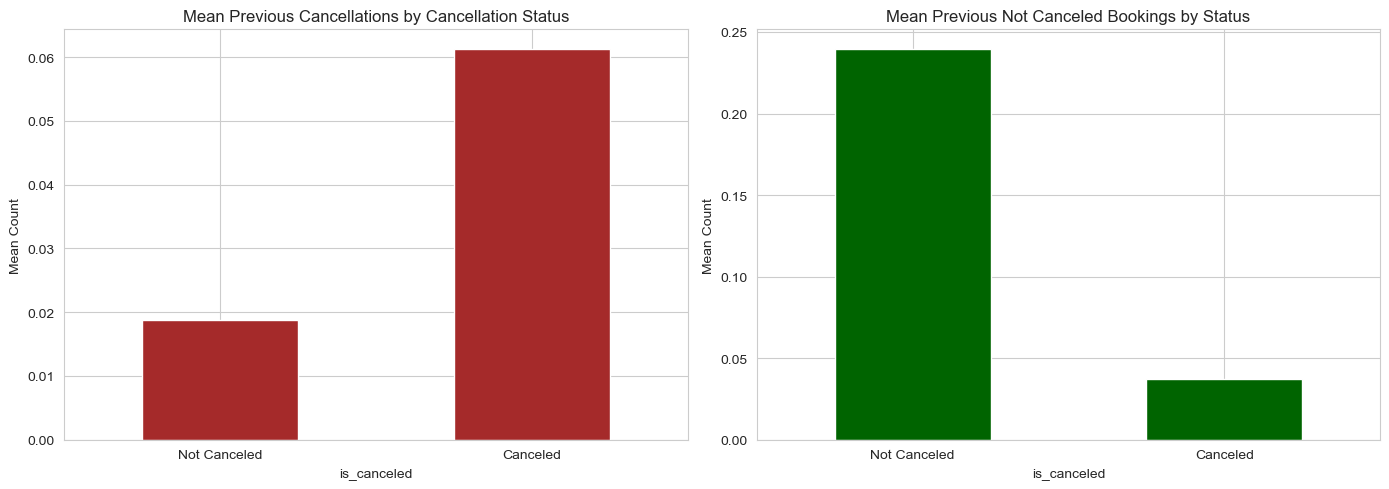

In [599]:
# Visual check of previous history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Previous cancellations rate
df_master.groupby('is_canceled')['previous_cancellations'].mean().plot(kind='bar', ax=axes[0], color='brown')
axes[0].set_title('Mean Previous Cancellations by Cancellation Status')
axes[0].set_ylabel('Mean Count')
axes[0].set_xlabel('is_canceled')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

# Previous bookings not canceled
df_master.groupby('is_canceled')['previous_bookings_not_canceled'].mean().plot(kind='bar', ax=axes[1], color='darkgreen')
axes[1].set_title('Mean Previous Not Canceled Bookings by Status')
axes[1].set_ylabel('Mean Count')
axes[1].set_xlabel('is_canceled')
axes[1].set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

plt.tight_layout()
plt.show()


### Prior Booking History vs `is_canceled` Analysis

#### **Insights**
- (Previous Cancellations):
  - Canceled bookings: Mean $0.061$ (Median: $0.0$, Max: $26.0$).
  - Non-canceled bookings: Mean $0.019$ (Median: $0.0$, Max: $13.0$).
  
- (Previous Bookings Not Canceled):
  - Canceled bookings: Mean $0.037$ (Median: $0.0$, Max: $58.0$).
  - Non-canceled bookings: Mean $0.240$ (Median: $0.0$, Max: $72.0$).
  
- While the direct statistical association of `previous_cancellations` and `previous_bookings_not_canceled` with `is_canceled` is 'Negligible / Very Weak', observed differences in mean values indicate that guests with prior cancellations tend to have a higher mean for `previous_cancellations` when `is_canceled` is 1, and a lower mean for `previous_bookings_not_canceled` when `is_canceled` is 1. This suggests that these features, while not strongly correlated on their own, can still provide valuable information, especially when used in feature engineering techniques like creating a `prev_cancel_ratio`.

In [600]:
# Create a dynamically calculated summary table for C10-C19
summary_data = [
    {   'Feature': 'C10: adults',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c10,
        'FE Action': 'Sum to create total_guests.'},
    {
        'Feature': 'C11: children',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c11,
        'FE Action': 'Impute 4 missing with mode 0.0; sum to create total_guests.'},
    {
        'Feature': 'C12: babies',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c12,
        'FE Action': 'Sum to create total_guests; create binary is_family.'},
    {
        'Feature': 'C13: meal',
        'Type': 'Categorical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c13,
        'FE Action': 'One-hot encode; consolidate FB and Undefined.'},
    {
        'Feature': 'C14: country',
        'Type': 'Categorical',
        'Test': 'Chi-Square',
        'Statistic': f"{chi2_c14:.2f}",
        'p-value': f"{p_c14:.4e}",
        'Effect Size (V or r)': f"{v_c14:.4f}",
        'Strength': str_c14,
        'FE Action': 'Impute 488 missing with mode/Unknown; target encode; create is_local.'},
    {
        'Feature': 'C15: market_segment',
        'Type': 'Categorical',
        'Test': 'Chi-Square',
        'Statistic': f"{chi2_c15:.2f}",
        'p-value': f"{p_c15:.4e}",
        'Effect Size (V or r)': f"{v_c15:.4f}",
        'Strength': str_c15,
        'FE Action': 'One-hot encode; group rare segments; build channel interaction.'},
    {
        'Feature': 'C16: distribution_channel',
        'Type': 'Categorical',
        'Test': 'Chi-Square',
        'Statistic': f"{chi2_c16:.2f}",
        'p-value': f"{p_c16:.4e}",
        'Effect Size (V or r)': f"{v_c16:.4f}",
        'Strength': str_c16,
        'FE Action': 'One-hot encode; build segment interaction.'},
    {
        'Feature': 'C17: is_repeated_guest',
        'Type': 'Categorical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c17,
        'FE Action': 'Keep as binary flag; use in loyalty score.'},
    {
        'Feature': 'C18: previous_cancellations',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c18,
        'FE Action': 'Create has_prev_cancellations flag; calculate cancellation ratio.'},
    {
        'Feature': 'C19: previous_bookings_not_canceled',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c19,
        'FE Action': 'Use in loyalty score and cancellation ratio.'}]

summary_df_master = pd.DataFrame(summary_data)

# Print Summary Table
print("="*150)
print("DYNAMICAL STATISTICAL SUMMARY TABLE: FEATURES C10-C19 VS TARGET (is_canceled)")
print("="*150)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 10)
print(summary_df_master.to_string(index=False))
print("="*150)

DYNAMICAL STATISTICAL SUMMARY TABLE: FEATURES C10-C19 VS TARGET (is_canceled)
                            Feature        Type                       Test Statistic    p-value Effect Size (V or r)               Strength                                                             FE Action
                        C10: adults   Numerical Not Required (Weak Effect)       N/A        N/A                  N/A Negligible / Very Weak                                           Sum to create total_guests.
                      C11: children   Numerical Not Required (Weak Effect)       N/A        N/A                  N/A Negligible / Very Weak           Impute 4 missing with mode 0.0; sum to create total_guests.
                        C12: babies   Numerical Not Required (Weak Effect)       N/A        N/A                  N/A Negligible / Very Weak                  Sum to create total_guests; create binary is_family.
                          C13: meal Categorical Not Required (Weak Effect)       N

In [4]:
import category_encoders as ce
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder


class DataFrameTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, target_column="is_canceled"):
        self.target_column = target_column
        self.one_hot_encoder_meal = None
        self.target_encoder_country = None
        self.one_hot_encoder_market_segment = None
        self.one_hot_encoder_distribution_channel = None

    def fit(self, X, y=None):
        X_fit = X.copy()

        # Handle missing values
        if "children" in X_fit.columns and X_fit["children"].isnull().any():
            X_fit["children"] = X_fit["children"].fillna(0.0)
        if "country" in X_fit.columns and X_fit["country"].isnull().any():
            X_fit["country"] = X_fit["country"].fillna("PRT")

        # Fit OneHotEncoder for 'meal'
        meal_modified = X_fit["meal"].replace(
            {"FB": "Other", "Undefined": "Other"}
        )
        self.one_hot_encoder_meal = OneHotEncoder(
            handle_unknown="ignore", sparse_output=False
        )
        self.one_hot_encoder_meal.fit(meal_modified.to_frame())

        # Fit TargetEncoder for 'country'
        if y is not None:
            self.target_encoder_country = ce.TargetEncoder(cols=["country"])
            self.target_encoder_country.fit(X_fit[["country"]], y)
        else:
            print(
                "Warning: Target column 'y' not provided for fitting TargetEncoder on 'country'."
            )

        # Fit OneHotEncoder for 'market_segment'
        self.one_hot_encoder_market_segment = OneHotEncoder(
            handle_unknown="ignore", sparse_output=False
        )
        self.one_hot_encoder_market_segment.fit(X_fit[["market_segment"]])

        # Fit OneHotEncoder for 'distribution_channel'
        self.one_hot_encoder_distribution_channel = OneHotEncoder(
            handle_unknown="ignore", sparse_output=False
        )
        self.one_hot_encoder_distribution_channel.fit(
            X_fit[["distribution_channel"]]
        )

        return self

    def transform(self, X):
        X_transformed = X.copy()

        # 0. Imputation
        if "children" in X_transformed.columns:
            X_transformed["children"] = X_transformed["children"].fillna(0.0)
        if "country" in X_transformed.columns:
            X_transformed["country"] = X_transformed["country"].fillna("PRT")

        # Store 'is_local_PRT' flag
        is_local_prt_feature = (X_transformed["country"] == "PRT").astype(int)

        # 1. Target Encoding for 'country'
        if self.target_encoder_country:
            X_transformed["country"] = self.target_encoder_country.transform(
                X_transformed[["country"]]
            )

        # 2. Add 'is_local_PRT'
        X_transformed["is_local_PRT"] = is_local_prt_feature

        # 3. Guest Features
        X_transformed["total_guests"] = (
            X_transformed["adults"]
            + X_transformed["children"]
            + X_transformed["babies"]
        )
        X_transformed["is_family"] = (
            (X_transformed["children"] > 0) | (X_transformed["babies"] > 0)
        ).astype(int)

        # 4. Meal Encoding
        meal_transformed = X_transformed["meal"].replace(
            {"FB": "Other", "Undefined": "Other"}
        )
        meal_encoded = self.one_hot_encoder_meal.transform(
            meal_transformed.to_frame()
        )
        meal_df = pd.DataFrame(
            meal_encoded,
            columns=self.one_hot_encoder_meal.get_feature_names_out(["meal"]),
            index=X_transformed.index,
        )
        X_transformed = pd.concat([X_transformed, meal_df], axis=1).drop(
            columns=["meal"]
        )

        # 5. Market Segment & Distribution Channel Encoding
        market_segment_encoded = (
            self.one_hot_encoder_market_segment.transform(
                X_transformed[["market_segment"]]
            )
        )
        market_segment_df = pd.DataFrame(
            market_segment_encoded,
            columns=self.one_hot_encoder_market_segment.get_feature_names_out(
                ["market_segment"]
            ),
            index=X_transformed.index,
        )
        X_transformed = pd.concat(
            [X_transformed, market_segment_df], axis=1
        ).drop(columns=["market_segment"])

        distribution_channel_encoded = (
            self.one_hot_encoder_distribution_channel.transform(
                X_transformed[["distribution_channel"]]
            )
        )
        distribution_channel_df = pd.DataFrame(
            distribution_channel_encoded,
            columns=self.one_hot_encoder_distribution_channel.get_feature_names_out(
                ["distribution_channel"]
            ),
            index=X_transformed.index,
        )
        X_transformed = pd.concat(
            [X_transformed, distribution_channel_df], axis=1
        ).drop(columns=["distribution_channel"])

        # 6. Interaction Feature
        if (
            "market_segment_Groups" in X_transformed.columns
            and "distribution_channel_TA/TO" in X_transformed.columns
        ):
            X_transformed["is_group_ta_to"] = (
                X_transformed["market_segment_Groups"]
                * X_transformed["distribution_channel_TA/TO"]
            )
        else:
            X_transformed["is_group_ta_to"] = 0

        # 7. Previous Booking History
        X_transformed["has_prev_cancellations"] = (
            X_transformed["previous_cancellations"] > 0
        ).astype(int)
        epsilon = 1e-5
        X_transformed["prev_cancel_ratio"] = X_transformed[
            "previous_cancellations"
        ] / (
            X_transformed["previous_cancellations"]
            + X_transformed["previous_bookings_not_canceled"]
            + epsilon
        )

        return X_transformed


# --- EXECUTION ---
# Assuming 'df' is your original loaded Kaggle DataFrame
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

transformer = DataFrameTransformer()
df_transformed = transformer.fit_transform(X, y)

print(df_transformed.head())

          hotel  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel        342               2015               July   
1  Resort Hotel        737               2015               July   
2  Resort Hotel          7               2015               July   
3  Resort Hotel         13               2015               July   
4  Resort Hotel         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  children  babies  \
0                        0                     0       2       0.0       0   
1                        0                     0       2       0.0       0   
2       

In [5]:
df_master = df_transformed.copy()

print("Head of df_master:")
display(df_master.head())

Head of df_master:


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_local_PRT,total_guests,is_family,meal_BB,meal_HB,meal_Other,meal_SC,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,is_group_ta_to,has_prev_cancellations,prev_cancel_ratio
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,0,0.562085,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,0,0.562085,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,0,0.202243,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,0,1.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,0,0.202243,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,0,1.0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.0
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,0,0.202243,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,0,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0.0


## Abdul's Analysis - End

--------------------------------------------------------------------------------------------------------------------

In [606]:
pd.DataFrame({
    'Column Names': df_master.columns,
    'Column Types': df_master.dtypes.values
})

,Column Names,Column Types
0,hotel,object
1,is_canceled,int64
2,lead_time,int64
3,arrival_date_year,int64
4,arrival_date_month,object
5,arrival_date_week_number,int64
6,arrival_date_day_of_month,int64
7,stays_in_weekend_nights,int64
8,stays_in_week_nights,int64
9,adults,int64
